In [ ]:
# Peak Day Intelligence — Fresh Build

## Goal

Build an explainable peak-day detection system from flown data.

We want to:
1. load the flown dataset
2. attach ICAO → cluster mapping cleanly
3. build usable economic metrics
4. detect peak days at:
   - network level
   - cluster level
5. compare peak vs non-peak baselines
6. explain peaks using:
   - revenue
   - flights
   - Rev/Hr
   - DOW
   - TOD
7. export a compact JSON packet for LLM reasoning later

## Design principles

- deterministic first
- comments everywhere
- inspect each layer before moving on
- do not over-engineer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

print("Libraries loaded.")

Libraries loaded.


In [2]:
# GCS paths
flown_path = "gs://agntworks-data-dev/sandbox/experiments/Completed-Flights-2016.xlsx"
mapping_path = "gs://agntworks-data-dev/sandbox/experiments/icao_cluster.csv"

# Load flown data
df_raw = pd.read_excel(flown_path, engine="openpyxl")

# Load ICAO-cluster lookup
map_df = pd.read_csv(mapping_path)

print("Flown rows:", len(df_raw))
print("Flown cols:", len(df_raw.columns))
print("Mapping rows:", len(map_df))
print("Mapping cols:", len(map_df.columns))

display(df_raw.head(3))
display(map_df.head(10))

Flown rows: 12806
Flown cols: 32
Mapping rows: 38859
Mapping cols: 2


,Quote_Number,Trip_Number,Trip_Legs_ID,Leg_Count,Leg_Number,DHflag,PAX_Count,Dep_ICAO,Dep_Lat,Dep_Long,Dep_region,Arr_ICAO,Arr_Lat,Arr_Long,Arr_region,Trip_type_code,Trip_Purpose,Aircraft_ID,Aircraft_Type_ID,Dep_Date_Actual_GMT,Dep_Time_Actual_GMT,Arr_Date_Actual_GMT,Arr_Time_Actual_GMT,TO_Time_Act_GMT,Land_Time_Act_GMT,Statute_Miles,Quote_Total_Cost,Equivalent_Rate_Cost,AC_Cost_Total,Owner_AC_Cost,Owner_AC_Cost_Fixed,Requester_Name_Key
0,520542,157565,42366991KODR3217,3,1,1,0,KBWI,391031255,764005990,7,MBPV,214625050,721557190,100,RETA,XPPB,549X,CL30,2016-01-01,23:37:00,2016-01-02,02:44:00,23:47:00,02:38:00,1227,44251.2,8571.43,67000.0,0.0,0,MACGREGOR MARY READ RE
1,520542,157565,420331372FOSJ3517,3,2,0,4,MBPV,214625050,721557190,100,KOPF,255426700,801641600,7,RETA,XPPB,549X,CL30,2016-01-02,18:00:00,2016-01-02,19:58:00,18:22:00,19:52:00,581,44251.2,8571.43,67000.0,0.0,0,MACGREGOR MARY READ RE
2,520542,157565,420331372FOSJ4217,3,3,0,4,KOPF,255426700,801641600,7,KOAK,374316534,1221316136,11,RETA,XPPB,549X,CL30,2016-01-02,20:42:00,2016-01-03,03:15:00,20:57:00,03:09:00,2574,44251.2,8571.43,67000.0,0.0,0,MACGREGOR MARY READ RE


,icao,cluster
0,00AA,DENVER_CLUSTER
1,00AK,OTHER_CLUSTER
2,00AL,ATLANTA_CLUSTER
3,00AN,OTHER_CLUSTER
4,00AS,DALLAS_CLUSTER
5,00AZ,PHOENIX_CLUSTER
6,00CA,LAS_VEGAS_CLUSTER
7,00CL,SAN_FRANCISCO_CLUSTER
8,00CN,SAN_DIEGO_CLUSTER
9,00FA,ORLANDO_CLUSTER


In [3]:
# Basic shape and core columns
required_cols = [
    "Trip_Legs_ID",
    "Dep_ICAO",
    "Arr_ICAO",
    "Dep_Date_Actual_GMT",
    "Dep_Time_Actual_GMT",
    "TO_Time_Act_GMT",
    "Land_Time_Act_GMT",
    "Quote_Total_Cost",
    "AC_Cost_Total"
]

missing_cols = [c for c in required_cols if c not in df_raw.columns]
print("Missing required columns:", missing_cols)

# Null % report for core columns
null_report = (
    df_raw[required_cols]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("null_pct")
    .reset_index()
    .rename(columns={"index": "column"})
)

display(null_report.sort_values("null_pct", ascending=False))

Missing required columns: []


,column,null_pct
0,Trip_Legs_ID,0.0
1,Dep_ICAO,0.0
2,Arr_ICAO,0.0
3,Dep_Date_Actual_GMT,0.0
4,Dep_Time_Actual_GMT,0.0
5,TO_Time_Act_GMT,0.0
6,Land_Time_Act_GMT,0.0
7,Quote_Total_Cost,0.0
8,AC_Cost_Total,0.0


In [4]:
df = df_raw.copy()

# Normalize ICAO keys on both sides
df["Dep_ICAO"] = df["Dep_ICAO"].astype(str).str.strip().str.upper()
df["Arr_ICAO"] = df["Arr_ICAO"].astype(str).str.strip().str.upper()

# Normalize mapping columns
map_df.columns = [c.strip() for c in map_df.columns]
map_df["icao"] = map_df["icao"].astype(str).str.strip().str.upper()
map_df["cluster"] = map_df["cluster"].astype(str).str.strip().str.upper()

# Drop duplicate ICAOs in mapping just in case
map_df = map_df.drop_duplicates(subset="icao", keep="last")

# Drop old cluster columns if they exist
df = df.drop(columns=["Dep_cluster", "Arr_cluster"], errors="ignore")

# Merge departure cluster
df = df.merge(
    map_df.rename(columns={"icao": "Dep_ICAO", "cluster": "Dep_cluster"}),
    on="Dep_ICAO",
    how="left"
)

# Merge arrival cluster
df = df.merge(
    map_df.rename(columns={"icao": "Arr_ICAO", "cluster": "Arr_cluster"}),
    on="Arr_ICAO",
    how="left"
)

print("Cluster merge complete.")
display(df[["Dep_ICAO", "Dep_cluster", "Arr_ICAO", "Arr_cluster"]].head(10))

Cluster merge complete.


,Dep_ICAO,Dep_cluster,Arr_ICAO,Arr_cluster
0,KBWI,WASHINGTON_DC_CLUSTER,MBPV,OTHER_CLUSTER
1,MBPV,OTHER_CLUSTER,KOPF,MIAMI_CLUSTER
2,KOPF,MIAMI_CLUSTER,KOAK,SAN_FRANCISCO_CLUSTER
3,KBED,BOSTON_CLUSTER,TVSC,OTHER_CLUSTER
4,TVSC,OTHER_CLUSTER,TJSJ,SAN_JUAN_CLUSTER
5,TJSJ,SAN_JUAN_CLUSTER,KFLL,MIAMI_CLUSTER
6,MBPV,OTHER_CLUSTER,TVSC,OTHER_CLUSTER
7,TVSC,OTHER_CLUSTER,KBED,BOSTON_CLUSTER
8,KBED,BOSTON_CLUSTER,KBED,BOSTON_CLUSTER
9,KFRG,NEW_YORK_CLUSTER,KBED,BOSTON_CLUSTER


In [5]:
# Missing cluster summary
dep_missing_pct = df["Dep_cluster"].isna().mean() * 100
arr_missing_pct = df["Arr_cluster"].isna().mean() * 100

print(f"Missing Dep_cluster %: {dep_missing_pct:.2f}%")
print(f"Missing Arr_cluster %: {arr_missing_pct:.2f}%")

# Top missing departure ICAOs by revenue
missing_dep = (
    df[df["Dep_cluster"].isna()]
    .groupby("Dep_ICAO", as_index=False)
    .agg(
        flights=("Trip_Legs_ID", "nunique"),
        revenue=("Quote_Total_Cost", "sum")
    )
    .sort_values("revenue", ascending=False)
)

# Top missing arrival ICAOs by revenue
missing_arr = (
    df[df["Arr_cluster"].isna()]
    .groupby("Arr_ICAO", as_index=False)
    .agg(
        flights=("Trip_Legs_ID", "nunique"),
        revenue=("Quote_Total_Cost", "sum")
    )
    .sort_values("revenue", ascending=False)
)

print("Top missing Dep ICAOs:")
display(missing_dep.head(20))

print("Top missing Arr ICAOs:")
display(missing_arr.head(20))

Missing Dep_cluster %: 0.00%
Missing Arr_cluster %: 0.00%
Top missing Dep ICAOs:


,Dep_ICAO,flights,revenue


Top missing Arr ICAOs:


,Arr_ICAO,flights,revenue


In [7]:
# Inspect raw date/time columns before doing any math
display(df[[
    "Dep_Date_Actual_GMT",
    "Dep_Time_Actual_GMT",
    "Arr_Date_Actual_GMT",
    "Arr_Time_Actual_GMT",
    "TO_Time_Act_GMT",
    "Land_Time_Act_GMT"
]].head(10))

print(df[[
    "Dep_Date_Actual_GMT",
    "Dep_Time_Actual_GMT",
    "Arr_Date_Actual_GMT",
    "Arr_Time_Actual_GMT",
    "TO_Time_Act_GMT",
    "Land_Time_Act_GMT"
]].dtypes)

,Dep_Date_Actual_GMT,Dep_Time_Actual_GMT,Arr_Date_Actual_GMT,Arr_Time_Actual_GMT,TO_Time_Act_GMT,Land_Time_Act_GMT
0,2016-01-01,23:37:00,2016-01-02,02:44:00,23:47:00,02:38:00
1,2016-01-02,18:00:00,2016-01-02,19:58:00,18:22:00,19:52:00
2,2016-01-02,20:42:00,2016-01-03,03:15:00,20:57:00,03:09:00
3,2016-01-10,14:56:00,2016-01-10,19:18:00,15:02:00,19:12:00
4,2016-01-10,21:10:00,2016-01-10,22:32:00,21:16:00,22:27:00
5,2016-01-10,23:20:00,2016-01-11,01:58:00,23:26:00,01:52:00
6,2016-01-16,16:54:00,2016-01-16,19:00:00,17:00:00,18:54:00
7,2016-01-17,17:48:00,2016-01-17,22:52:00,17:54:00,22:46:00
8,2016-01-17,23:16:00,2016-01-17,23:16:00,23:16:00,23:16:00
9,2016-02-01,12:40:00,2016-02-01,13:23:00,12:46:00,13:19:00


Dep_Date_Actual_GMT    datetime64[ns]
Dep_Time_Actual_GMT            object
Arr_Date_Actual_GMT    datetime64[ns]
Arr_Time_Actual_GMT            object
TO_Time_Act_GMT                object
Land_Time_Act_GMT              object
dtype: object


In [8]:
# Parse date fields
df["Dep_Date_dt"] = pd.to_datetime(df["Dep_Date_Actual_GMT"], errors="coerce")
df["Arr_Date_dt"] = pd.to_datetime(df["Arr_Date_Actual_GMT"], errors="coerce")

# Helper: convert a time-like field into "HH:MM:SS" text
def normalize_time_value(x):
    if pd.isna(x):
        return None

    # already a timestamp/time-like object
    ts = pd.to_datetime(x, errors="coerce")
    if pd.notna(ts):
        return ts.strftime("%H:%M:%S")

    # fallback to raw string
    s = str(x).strip()
    return s if s else None

df["TO_Time_str"] = df["TO_Time_Act_GMT"].apply(normalize_time_value)
df["Land_Time_str"] = df["Land_Time_Act_GMT"].apply(normalize_time_value)

# Build full timestamps by combining actual date + actual time
df["TO_TS"] = pd.to_datetime(
    df["Dep_Date_dt"].dt.strftime("%Y-%m-%d") + " " + df["TO_Time_str"],
    errors="coerce"
)

df["LAND_TS"] = pd.to_datetime(
    df["Arr_Date_dt"].dt.strftime("%Y-%m-%d") + " " + df["Land_Time_str"],
    errors="coerce"
)

# Compute block hours
df["Block_Hours"] = (df["LAND_TS"] - df["TO_TS"]).dt.total_seconds() / 3600

display(df[[
    "Dep_Date_Actual_GMT",
    "TO_Time_Act_GMT",
    "TO_TS",
    "Arr_Date_Actual_GMT",
    "Land_Time_Act_GMT",
    "LAND_TS",
    "Block_Hours"
]].head(10))

,Dep_Date_Actual_GMT,TO_Time_Act_GMT,TO_TS,Arr_Date_Actual_GMT,Land_Time_Act_GMT,LAND_TS,Block_Hours
0,2016-01-01,23:47:00,2016-01-01 23:47:00,2016-01-02,02:38:00,2016-01-02 02:38:00,2.850000
1,2016-01-02,18:22:00,2016-01-02 18:22:00,2016-01-02,19:52:00,2016-01-02 19:52:00,1.500000
2,2016-01-02,20:57:00,2016-01-02 20:57:00,2016-01-03,03:09:00,2016-01-03 03:09:00,6.200000
3,2016-01-10,15:02:00,2016-01-10 15:02:00,2016-01-10,19:12:00,2016-01-10 19:12:00,4.166667
4,2016-01-10,21:16:00,2016-01-10 21:16:00,2016-01-10,22:27:00,2016-01-10 22:27:00,1.183333
5,2016-01-10,23:26:00,2016-01-10 23:26:00,2016-01-11,01:52:00,2016-01-11 01:52:00,2.433333
6,2016-01-16,17:00:00,2016-01-16 17:00:00,2016-01-16,18:54:00,2016-01-16 18:54:00,1.900000
7,2016-01-17,17:54:00,2016-01-17 17:54:00,2016-01-17,22:46:00,2016-01-17 22:46:00,4.866667
8,2016-01-17,23:16:00,2016-01-17 23:16:00,2016-01-17,23:16:00,2016-01-17 23:16:00,0.000000
9,2016-02-01,12:46:00,2016-02-01 12:46:00,2016-02-01,13:19:00,2016-02-01 13:19:00,0.550000


In [9]:
print("Null Block_Hours %:", round(df["Block_Hours"].isna().mean() * 100, 2))
print("Negative Block_Hours %:", round((df["Block_Hours"] < 0).mean() * 100, 2))

display(df["Block_Hours"].describe())

# Show suspicious rows
display(df[df["Block_Hours"].isna()][[
    "Trip_Legs_ID",
    "Dep_Date_Actual_GMT",
    "TO_Time_Act_GMT",
    "Arr_Date_Actual_GMT",
    "Land_Time_Act_GMT"
]].head(20))

Null Block_Hours %: 0.0
Negative Block_Hours %: 0.0


count    12806.000000
mean         2.316701
std          2.902916
min          0.000000
25%          0.833333
50%          1.800000
75%          3.000000
max         29.816667
Name: Block_Hours, dtype: float64

,Trip_Legs_ID,Dep_Date_Actual_GMT,TO_Time_Act_GMT,Arr_Date_Actual_GMT,Land_Time_Act_GMT


In [11]:
# How many times does the same revenue repeat?
rev_counts = df.groupby("Quote_Total_Cost").size().reset_index(name="count")

display(rev_counts.sort_values("count", ascending=False).head(20))

,Quote_Total_Cost,count
1,0.0,1521
340,12500.0,72
536,15000.0,55
1266,22000.0,51
2114,30000.0,39
1470,24000.0,38
818,18000.0,38
1038,20000.0,37
1580,25000.0,37
182,10000.0,35


In [12]:
trip_rev_check = (
    df.groupby("Trip_Number")["Quote_Total_Cost"]
    .nunique()
    .reset_index(name="unique_revenue_values")
)

display(trip_rev_check["unique_revenue_values"].value_counts())

unique_revenue_values
1    6167
Name: count, dtype: int64

In [15]:
df["trip_total_block_hours"] = df.groupby("Trip_Number")["Block_Hours"].transform("sum")

df["Revenue_allocated"] = (
    df["Quote_Total_Cost"] * (df["Block_Hours"] / df["trip_total_block_hours"])
)

In [16]:
df["RevHr_clean"] = df["Revenue_allocated"] / df["Block_Hours"]

In [17]:
display(df["Block_Hours"].describe())

print("Null %:", round(df["Block_Hours"].isna().mean()*100, 2))
print("Negative %:", round((df["Block_Hours"] < 0).mean()*100, 2))

count    12806.000000
mean         2.316701
std          2.902916
min          0.000000
25%          0.833333
50%          1.800000
75%          3.000000
max         29.816667
Name: Block_Hours, dtype: float64

Null %: 0.0
Negative %: 0.0


In [18]:
display(df["Quote_Total_Cost"].describe())

count     12806.000000
mean      35175.296765
std       37288.882627
min        -295.000000
25%       17190.722500
50%       29124.370000
75%       45162.365000
max      673872.350000
Name: Quote_Total_Cost, dtype: float64

In [19]:
df.groupby("Trip_Number")["Quote_Total_Cost"].nunique().value_counts()

Quote_Total_Cost
1    6167
Name: count, dtype: int64

In [20]:
print("Dep cluster missing %:", round(df["Dep_cluster"].isna().mean()*100, 2))
print("Arr cluster missing %:", round(df["Arr_cluster"].isna().mean()*100, 2))

Dep cluster missing %: 0.0
Arr cluster missing %: 0.0


In [21]:
df_clean = df.copy()

df_clean = df_clean[
    (df_clean["Block_Hours"] > 0) &
    (df_clean["Quote_Total_Cost"] > 0)
]

print("Rows:", len(df_clean))

Rows: 10794


In [22]:
network_day = (
    df_clean
    .groupby("dep_date", as_index=False)
    .agg(
        flights=("Trip_Legs_ID", "nunique"),
        revenue=("Quote_Total_Cost", "sum")
    )
)

network_day["rev_per_flight"] = network_day["revenue"] / network_day["flights"]

display(network_day.head())
display(network_day.describe())

,dep_date,flights,revenue,rev_per_flight
0,2016-01-01,58,2064534.15,35595.416379
1,2016-01-02,100,4554179.66,45541.796600
2,2016-01-03,95,3352228.69,35286.617789
3,2016-01-04,75,3076753.48,41023.379733
4,2016-01-05,56,2060793.77,36799.888750


,flights,revenue,rev_per_flight
count,182.000000,1.820000e+02,182.000000
mean,59.307692,2.369255e+06,39770.556806
std,11.021518,6.330400e+05,6346.618672
min,31.000000,9.784953e+05,24058.805667
25%,52.000000,1.953800e+06,35370.798435
50%,59.000000,2.231578e+06,38674.461479
75%,65.000000,2.741898e+06,43734.186902
max,100.000000,4.691423e+06,59172.155690


In [23]:
pd.options.display.float_format = '{:,.0f}'.format

In [24]:
network_day.describe()

,flights,revenue,rev_per_flight
count,182,182,182
mean,59,"2,369,255","39,771"
std,11,"633,040","6,347"
min,31,"978,495","24,059"
25%,52,"1,953,800","35,371"
50%,59,"2,231,578","38,674"
75%,65,"2,741,898","43,734"
max,100,"4,691,423","59,172"


In [25]:
cluster_day = (
    df_clean
    .groupby(["dep_date", "Dep_cluster"], as_index=False)
    .agg(
        flights=("Trip_Legs_ID", "nunique"),
        revenue=("Quote_Total_Cost", "sum")
    )
)

cluster_day["rev_per_flight"] = cluster_day["revenue"] / cluster_day["flights"]

display(cluster_day.head())

,dep_date,Dep_cluster,flights,revenue,rev_per_flight
0,2016-01-01,ASPEN_CLUSTER,3,"69,839","23,280"
1,2016-01-01,BOSTON_CLUSTER,4,"201,213","50,303"
2,2016-01-01,CABO_CLUSTER,1,"40,722","40,722"
3,2016-01-01,CHICAGO_CLUSTER,4,"142,569","35,642"
4,2016-01-01,DALLAS_CLUSTER,1,"21,167","21,167"


In [26]:
thresholds = {
    "flights_p90": network_day["flights"].quantile(0.9),
    "revenue_p90": network_day["revenue"].quantile(0.9)
}

network_day["peak_flag"] = (
    (network_day["flights"] >= thresholds["flights_p90"]) |
    (network_day["revenue"] >= thresholds["revenue_p90"])
).astype(int)

display(network_day.sort_values("revenue", ascending=False).head(20))

,dep_date,flights,revenue,rev_per_flight,peak_flag
17,2016-01-18,84,"4,691,423","55,850",1
1,2016-01-02,100,"4,554,180","45,542",1
139,2016-05-19,78,"4,309,824","55,254",1
171,2016-06-20,74,"4,037,504","54,561",1
14,2016-01-15,70,"4,033,244","57,618",1
41,2016-02-11,81,"3,701,490","45,697",1
42,2016-02-12,88,"3,592,846","40,828",1
78,2016-03-19,76,"3,559,304","46,833",1
18,2016-01-19,69,"3,551,341","51,469",1
54,2016-02-24,62,"3,435,504","55,411",1


In [27]:
network_day.sort_values("revenue", ascending=False).head(10)

,dep_date,flights,revenue,rev_per_flight,peak_flag
17,2016-01-18,84,"4,691,423","55,850",1
1,2016-01-02,100,"4,554,180","45,542",1
139,2016-05-19,78,"4,309,824","55,254",1
171,2016-06-20,74,"4,037,504","54,561",1
14,2016-01-15,70,"4,033,244","57,618",1
41,2016-02-11,81,"3,701,490","45,697",1
42,2016-02-12,88,"3,592,846","40,828",1
78,2016-03-19,76,"3,559,304","46,833",1
18,2016-01-19,69,"3,551,341","51,469",1
54,2016-02-24,62,"3,435,504","55,411",1


In [28]:
network_day.sort_values("flights", ascending=False).head(10)

,dep_date,flights,revenue,rev_per_flight,peak_flag
1,2016-01-02,100,"4,554,180","45,542",1
2,2016-01-03,95,"3,352,229","35,287",1
42,2016-02-12,88,"3,592,846","40,828",1
17,2016-01-18,84,"4,691,423","55,850",1
146,2016-05-26,83,"2,925,645","35,249",1
83,2016-03-24,82,"2,970,985","36,232",1
41,2016-02-11,81,"3,701,490","45,697",1
46,2016-02-16,80,"3,149,267","39,366",1
168,2016-06-17,79,"3,404,405","43,094",1
139,2016-05-19,78,"4,309,824","55,254",1


In [29]:
network_day[network_day["peak_flag"] == 1]

,dep_date,flights,revenue,rev_per_flight,peak_flag
1,2016-01-02,100,"4,554,180","45,542",1
2,2016-01-03,95,"3,352,229","35,287",1
3,2016-01-04,75,"3,076,753","41,023",1
13,2016-01-14,61,"3,166,583","51,911",1
14,2016-01-15,70,"4,033,244","57,618",1
17,2016-01-18,84,"4,691,423","55,850",1
18,2016-01-19,69,"3,551,341","51,469",1
20,2016-01-21,58,"3,431,985","59,172",1
41,2016-02-11,81,"3,701,490","45,697",1
42,2016-02-12,88,"3,592,846","40,828",1


In [31]:
# --- NETWORK PEAK DETECTION (CLEAN + EXPLAINABLE) ---

# 1. Compute thresholds (percentile-based)
thresholds = {
    "flights_p90": network_day["flights"].quantile(0.90),
    "revenue_p90": network_day["revenue"].quantile(0.90),
    "revpf_p75": network_day["rev_per_flight"].quantile(0.75)
}

print("Thresholds:")
for k, v in thresholds.items():
    print(f"{k}: {v:,.0f}")

# 2. Peak flag (business logic)
network_day["peak_flag"] = (
    (network_day["revenue"] >= thresholds["revenue_p90"]) |
    (
        (network_day["flights"] >= thresholds["flights_p90"]) &
        (network_day["rev_per_flight"] >= thresholds["revpf_p75"])
    )
).astype(int)

# 3. Baseline metrics (for context)
network_day["rev_vs_avg"] = (
    network_day["revenue"] / network_day["revenue"].mean()
)

network_day["flights_vs_avg"] = (
    network_day["flights"] / network_day["flights"].mean()
)

# 4. Z-score (optional statistical context)
network_day["revenue_zscore"] = (
    (network_day["revenue"] - network_day["revenue"].mean()) /
    network_day["revenue"].std()
)

# 5. Reason tagging (human readable)
network_day["peak_reason"] = ""

network_day.loc[
    network_day["revenue"] >= thresholds["revenue_p90"],
    "peak_reason"
] += "HIGH_REVENUE;"

network_day.loc[
    (network_day["flights"] >= thresholds["flights_p90"]) &
    (network_day["rev_per_flight"] >= thresholds["revpf_p75"]),
    "peak_reason"
] += "HIGH_VOLUME_QUALITY;"

# 6. Final view (sorted)
peak_view = network_day[network_day["peak_flag"] == 1] \
    .sort_values("revenue", ascending=False)

# 7. Display top peaks
print("\nTop Peak Days:")
display(
    peak_view[[
        "dep_date",
        "flights",
        "revenue",
        "rev_per_flight",
        "rev_vs_avg",
        "revenue_zscore",
        "peak_flag",
        "peak_reason"
    ]].head(20)
)

# 8. Summary stats
print("\nPeak vs Non-Peak Summary:")
summary = (
    network_day
    .groupby("peak_flag")
    .agg(
        days=("dep_date", "count"),
        avg_revenue=("revenue", "mean"),
        avg_flights=("flights", "mean"),
        avg_rev_per_flight=("rev_per_flight", "mean")
    )
)

display(summary)

Thresholds:
flights_p90: 74
revenue_p90: 3,165,648
revpf_p75: 43,734

Top Peak Days:


,dep_date,flights,revenue,rev_per_flight,rev_vs_avg,revenue_zscore,peak_flag,peak_reason
17,2016-01-18,84,"4,691,423","55,850",2,4,1,HIGH_REVENUE;HIGH_VOLUME_QUALITY;
1,2016-01-02,100,"4,554,180","45,542",2,3,1,HIGH_REVENUE;HIGH_VOLUME_QUALITY;
139,2016-05-19,78,"4,309,824","55,254",2,3,1,HIGH_REVENUE;HIGH_VOLUME_QUALITY;
171,2016-06-20,74,"4,037,504","54,561",2,3,1,HIGH_REVENUE;HIGH_VOLUME_QUALITY;
14,2016-01-15,70,"4,033,244","57,618",2,3,1,HIGH_REVENUE;
41,2016-02-11,81,"3,701,490","45,697",2,2,1,HIGH_REVENUE;HIGH_VOLUME_QUALITY;
42,2016-02-12,88,"3,592,846","40,828",2,2,1,HIGH_REVENUE;
78,2016-03-19,76,"3,559,304","46,833",2,2,1,HIGH_REVENUE;HIGH_VOLUME_QUALITY;
18,2016-01-19,69,"3,551,341","51,469",1,2,1,HIGH_REVENUE;
54,2016-02-24,62,"3,435,504","55,411",1,2,1,HIGH_REVENUE;



Peak vs Non-Peak Summary:


,days,avg_revenue,avg_flights,avg_rev_per_flight
peak_flag,,,,
0,163,"2,221,582",57,"38,712"
1,19,"3,636,136",75,"48,855"


In [32]:
peak_view["rev_vs_avg"] = peak_view["rev_vs_avg"].round(2)
peak_view["revenue_zscore"] = peak_view["revenue_zscore"].round(2)

In [33]:
# ------------------------------------------------------------
# Build a compact JSON payload for Gemini reasoning
# ------------------------------------------------------------
# Goal:
# Send only the most relevant peak-day fields, not the whole dataframe.
# Keep payload small and interpretable.
# ------------------------------------------------------------

peak_view = (
    network_day[network_day["peak_flag"] == 1]
    .sort_values("revenue", ascending=False)
    .copy()
)

# keep a compact top-N slice
peak_payload_df = peak_view[[
    "dep_date",
    "flights",
    "revenue",
    "rev_per_flight",
    "rev_vs_avg",
    "revenue_zscore",
    "peak_reason"
]].head(25).copy()

# round for readability
peak_payload_df["revenue"] = peak_payload_df["revenue"].round(0)
peak_payload_df["rev_per_flight"] = peak_payload_df["rev_per_flight"].round(0)
peak_payload_df["rev_vs_avg"] = peak_payload_df["rev_vs_avg"].round(2)
peak_payload_df["revenue_zscore"] = peak_payload_df["revenue_zscore"].round(2)

peak_payload = peak_payload_df.to_dict(orient="records")

print("Payload preview:")
print(json.dumps(peak_payload[:5], indent=2, default=str))

Payload preview:
[
  {
    "dep_date": "2016-01-18",
    "flights": 84,
    "revenue": 4691423.0,
    "rev_per_flight": 55850.0,
    "rev_vs_avg": 1.98,
    "revenue_zscore": 3.67,
    "peak_reason": "HIGH_REVENUE;HIGH_VOLUME_QUALITY;"
  },
  {
    "dep_date": "2016-01-02",
    "flights": 100,
    "revenue": 4554180.0,
    "rev_per_flight": 45542.0,
    "rev_vs_avg": 1.92,
    "revenue_zscore": 3.45,
    "peak_reason": "HIGH_REVENUE;HIGH_VOLUME_QUALITY;"
  },
  {
    "dep_date": "2016-05-19",
    "flights": 78,
    "revenue": 4309824.0,
    "rev_per_flight": 55254.0,
    "rev_vs_avg": 1.82,
    "revenue_zscore": 3.07,
    "peak_reason": "HIGH_REVENUE;HIGH_VOLUME_QUALITY;"
  },
  {
    "dep_date": "2016-06-20",
    "flights": 74,
    "revenue": 4037504.0,
    "rev_per_flight": 54561.0,
    "rev_vs_avg": 1.7,
    "revenue_zscore": 2.64,
    "peak_reason": "HIGH_REVENUE;HIGH_VOLUME_QUALITY;"
  },
  {
    "dep_date": "2016-01-15",
    "flights": 70,
    "revenue": 4033244.0,
    "rev_per_f

In [34]:
# ------------------------------------------------------------
# Gemini setup
# ------------------------------------------------------------
# If needed:
# !pip install -q google-genai
# ------------------------------------------------------------

from google import genai
from google.genai import types

client = genai.Client(vertexai=True, project="agntworks-dev", location="us-central1")

In [45]:
# ------------------------------------------------------------
# Prompt for Gemini
# ------------------------------------------------------------

system_prompt = """
You are a senior aviation revenue strategist.

You are analyzing peak flight days using only the provided data.

CRITICAL INSTRUCTIONS:

1. For each date:
   - First identify if it aligns with a known US holiday or travel period
     (e.g., New Year, MLK, Presidents Day, Spring Break, Summer start)
   - If unsure, say "uncertain"

2. Then classify demand driver:
   - ski / mountain travel
   - beach / leisure travel
   - general long-weekend travel
   - business / mixed

3. Explicitly separate:
   - yield-driven peaks
   - volume-driven peaks
   - mixed peaks

4. Do NOT assume all weekends are the same.
5. Do NOT fabricate specific destinations.

Return:

A. Executive summary

B. Formatted Table with readability:
date | inferred_holiday | demand_type | peak_type (yield/volume/mixed) | reasoning

C. Key patterns across all peaks

D. Top 3 hypotheses to validate with cluster-level data

CRITICAL CONSTRAINT:

- You DO NOT have route-level or destination data.
- You MUST NOT confidently assign specific travel types (e.g., ski, beach, conference)
  unless it is strongly implied by the calendar.

- If uncertain, use:
  "leisure (likely)"
  "business (possible)"
  "unknown"

- Clearly separate:
  - evidence-based conclusions
  - hypotheses requiring validation
  
"""

user_prompt = f"""
Here is the network peak-day payload:

{json.dumps(peak_payload, indent=2, default=str)}

Please analyze what appears to be going on.
"""

In [46]:
# ------------------------------------------------------------
# Send to Gemini
# ------------------------------------------------------------

response = client.models.generate_content(
    model="gemini-2.5-pro",
    contents=[
        types.Content(role="user", parts=[types.Part(text=system_prompt + "\n\n" + user_prompt)])
    ]
)

print(response.text)

To the Revenue Management Leadership Team,

This memorandum provides an analysis of network peak revenue days for the first half of 2016, based on the provided system-level data.

### A. Executive Summary

Our analysis reveals that peak revenue days are driven by two primary phenomena: major US holiday travel periods and distinct, high-yield mid-week demand surges.

The most significant revenue days are **mixed peaks**, combining both high passenger volume and exceptionally strong yields. These are concentrated on the return leg of holiday weekends, particularly the Mondays of Martin Luther King Jr. Day and Presidents' Day. This indicates significant pricing power on constrained, must-fly return dates.

A second category of peaks is purely **yield-driven**, characterized by the highest revenue-per-flight metrics in the dataset but on low flight volumes. These occur on mid-week days (Wednesdays/Thursdays) and are not associated with major holidays, strongly suggesting they are driven by

In [47]:
# ------------------------------------------------------------
# Build network-day metrics + regime classification
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# network aggregation
network_day = df.groupby("dep_date").agg(
    flights=("Trip_Legs_ID","nunique"),
    revenue=("Quote_Total_Cost","sum")
).reset_index()

network_day["rev_per_flight"] = network_day["revenue"] / network_day["flights"]

# baseline
avg_rev = network_day["revenue"].mean()
std_rev = network_day["revenue"].std()

avg_rpf = network_day["rev_per_flight"].mean()

# features
network_day["rev_vs_avg"] = network_day["revenue"] / avg_rev
network_day["revenue_zscore"] = (network_day["revenue"] - avg_rev) / std_rev

# regime classifier (keep simple + stable)
def classify_regime(row):
    if row["revenue_zscore"] >= 2:
        return "PEAK_MIXED"
    elif row["rev_per_flight"] >= 1.25 * avg_rpf:
        return "HIGH_YIELD"
    elif row["flights"] >= network_day["flights"].quantile(0.85):
        return "HIGH_VOLUME"
    else:
        return "NORMAL"

network_day["regime"] = network_day.apply(classify_regime, axis=1)

network_day["regime"].value_counts()

regime
NORMAL         139
HIGH_VOLUME     27
HIGH_YIELD       9
PEAK_MIXED       7
Name: count, dtype: int64

In [48]:
# ------------------------------------------------------------
# Attach regime to each flight row
# ------------------------------------------------------------

df = df.merge(
    network_day[["dep_date","regime"]],
    on="dep_date",
    how="left"
)

df["regime"].isna().sum()  # should be 0

np.int64(0)

In [51]:
print(df.columns.tolist())

['Quote_Number', 'Trip_Number', 'Trip_Legs_ID', 'Leg_Count', 'Leg_Number', 'DHflag', 'PAX_Count', 'Dep_ICAO', 'Dep_Lat', 'Dep_Long', 'Dep_region', 'Arr_ICAO', 'Arr_Lat', 'Arr_Long', 'Arr_region', 'Trip_type_code', 'Trip_Purpose', 'Aircraft_ID', 'Aircraft_Type_ID', 'Dep_Date_Actual_GMT', 'Dep_Time_Actual_GMT', 'Arr_Date_Actual_GMT', 'Arr_Time_Actual_GMT', 'TO_Time_Act_GMT', 'Land_Time_Act_GMT', 'Statute_Miles', 'Quote_Total_Cost', 'Equivalent_Rate_Cost', 'AC_Cost_Total', 'Owner_AC_Cost', 'Owner_AC_Cost_Fixed', 'Requester_Name_Key', 'Dep_cluster', 'Arr_cluster', 'Dep_Date_dt', 'Dep_Time_dt', 'TO_Time_dt', 'Land_Time_dt', 'dep_date', 'Block_Hours', 'Contribution', 'RevHr', 'ContribHr', 'Arr_Date_dt', 'TO_Time_str', 'Land_Time_str', 'TO_TS', 'LAND_TS', 'trip_total_block_hours', 'Revenue_allocated', 'RevHr_clean', 'regime']


In [52]:
df["dep_date"] = pd.to_datetime(df["dep_date"])
df["dow"] = df["dep_date"].dt.day_name()  # or .dt.weekday (0–6)

In [54]:
df[["dep_date", "regime"]].head()

,dep_date,regime
0,2016-01-01,NORMAL
1,2016-01-02,PEAK_MIXED
2,2016-01-02,PEAK_MIXED
3,2016-01-10,NORMAL
4,2016-01-10,NORMAL


In [59]:
print(network_day.columns.tolist())

['dep_date', 'flights', 'revenue', 'rev_per_flight', 'rev_vs_avg', 'revenue_zscore', 'regime']


In [60]:
df["dep_date"] = pd.to_datetime(df["dep_date"]).dt.normalize()
network_day["dep_date"] = pd.to_datetime(network_day["dep_date"]).dt.normalize()

In [61]:
test_merge = df.merge(
    network_day[["dep_date","regime"]],
    on="dep_date",
    how="left"
)

print(test_merge.columns.tolist())
print(test_merge["regime"].isna().sum())
print(len(test_merge))

['Quote_Number', 'Trip_Number', 'Trip_Legs_ID', 'Leg_Count', 'Leg_Number', 'DHflag', 'PAX_Count', 'Dep_ICAO', 'Dep_Lat', 'Dep_Long', 'Dep_region', 'Arr_ICAO', 'Arr_Lat', 'Arr_Long', 'Arr_region', 'Trip_type_code', 'Trip_Purpose', 'Aircraft_ID', 'Aircraft_Type_ID', 'Dep_Date_Actual_GMT', 'Dep_Time_Actual_GMT', 'Arr_Date_Actual_GMT', 'Arr_Time_Actual_GMT', 'TO_Time_Act_GMT', 'Land_Time_Act_GMT', 'Statute_Miles', 'Quote_Total_Cost', 'Equivalent_Rate_Cost', 'AC_Cost_Total', 'Owner_AC_Cost', 'Owner_AC_Cost_Fixed', 'Requester_Name_Key', 'Dep_cluster', 'Arr_cluster', 'Dep_Date_dt', 'Dep_Time_dt', 'TO_Time_dt', 'Land_Time_dt', 'dep_date', 'Block_Hours', 'Contribution', 'RevHr', 'ContribHr', 'Arr_Date_dt', 'TO_Time_str', 'Land_Time_str', 'TO_TS', 'LAND_TS', 'trip_total_block_hours', 'Revenue_allocated', 'RevHr_clean', 'regime_x', 'dow', 'regime_y', 'regime']
0
12806


In [62]:
df["dep_date_str"] = df["dep_date"].astype(str)
network_day["dep_date_str"] = network_day["dep_date"].astype(str)

df = df.merge(
    network_day[["dep_date_str","regime"]],
    on="dep_date_str",
    how="left"
)

In [63]:
network_day["regime"] = network_day.apply(classify_regime, axis=1)

In [64]:
df["regime"].value_counts(dropna=False)

regime
NORMAL         9266
HIGH_VOLUME    2345
PEAK_MIXED      631
HIGH_YIELD      564
Name: count, dtype: int64

In [65]:
network_day.groupby("regime")[["flights","revenue","rev_per_flight"]].mean()

,flights,revenue,rev_per_flight
regime,,,
HIGH_VOLUME,87,"3,082,834","35,450"
HIGH_YIELD,63,"2,989,034","47,543"
NORMAL,67,"2,232,391","33,481"
PEAK_MIXED,90,"4,287,815","47,695"


----- MEAN vs MEDIAN -----
Mean:   2,475,027
Median: 2,334,454
Mean / Median Ratio: 1.06
→ Suggests RIGHT-SKEW (tail on higher values)

----- SKEWNESS -----
Skew: 0.950
→ Moderately right-skewed

----- PERCENTILE SPREAD -----
P10: 1,755,577
P50: 2,334,454
P90: 3,334,312
Upper Spread (P90 - P50): 999,858
Lower Spread (P50 - P10): 578,877
Upper / Lower Ratio: 1.73
→ Right tail is longer


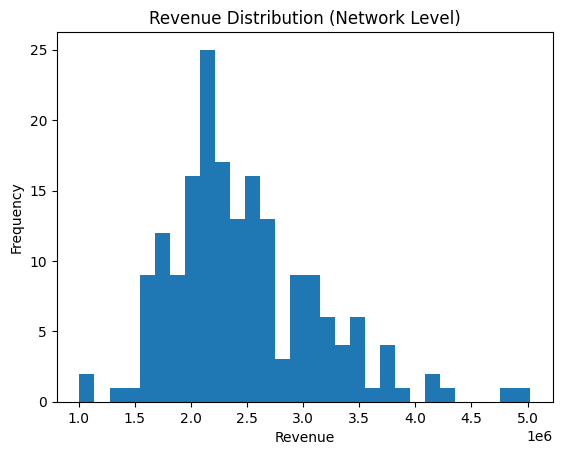


----- FINAL INTERPRETATION -----
✔ Distribution is LIKELY RIGHT-TAILED


In [67]:
# ------------------------------------------------------------
# DISTRIBUTION DIAGNOSTICS — "IS THIS RIGHT-TAILED?"
# ------------------------------------------------------------
# Goal:
# Validate whether `network_day["revenue"]` is right-skewed
# using multiple independent checks.
#
# Why this matters:
# - Right-tailed → few large peak days dominate upside
# - Justifies regime separation (peak vs normal)
# - Prevents misleading averages in Cone 1
#
# This chunk combines:
# 1) Mean vs Median check
# 2) Skewness (statistical)
# 3) Percentile spread asymmetry
# 4) Quick histogram visualization
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# INPUT SERIES
# ------------------------------------------------------------
s = network_day["revenue"].dropna()

# ------------------------------------------------------------
# 1) MEAN vs MEDIAN CHECK
# ------------------------------------------------------------
# Right-tailed distributions typically have:
# mean > median (because high outliers pull the mean up)

mean_val = s.mean()
median_val = s.median()
ratio = mean_val / median_val

print("----- MEAN vs MEDIAN -----")
print(f"Mean:   {mean_val:,.0f}")
print(f"Median: {median_val:,.0f}")
print(f"Mean / Median Ratio: {ratio:.2f}")

if mean_val > median_val:
    print("→ Suggests RIGHT-SKEW (tail on higher values)")
elif mean_val < median_val:
    print("→ Suggests LEFT-SKEW")
else:
    print("→ Likely symmetric")

# ------------------------------------------------------------
# 2) SKEWNESS (NUMERICAL MEASURE)
# ------------------------------------------------------------
# Positive skew → right tail
# Negative skew → left tail

try:
    from scipy.stats import skew
    skew_val = skew(s)
except ImportError:
    # fallback (manual skew calculation)
    skew_val = ((s - mean_val)**3).mean() / (s.std()**3)

print("\n----- SKEWNESS -----")
print(f"Skew: {skew_val:.3f}")

if skew_val > 0.5:
    print("→ Moderately right-skewed")
elif skew_val > 0:
    print("→ Slight right-skew")
elif skew_val < -0.5:
    print("→ Moderately left-skewed")
elif skew_val < 0:
    print("→ Slight left-skew")
else:
    print("→ Approximately symmetric")

# ------------------------------------------------------------
# 3) PERCENTILE SPREAD CHECK
# ------------------------------------------------------------
# Compare:
# upper spread = p90 - p50
# lower spread = p50 - p10
#
# If upper > lower → longer right tail

p10 = s.quantile(0.10)
p50 = s.quantile(0.50)
p90 = s.quantile(0.90)

upper_spread = p90 - p50
lower_spread = p50 - p10
spread_ratio = upper_spread / lower_spread if lower_spread != 0 else np.nan

print("\n----- PERCENTILE SPREAD -----")
print(f"P10: {p10:,.0f}")
print(f"P50: {p50:,.0f}")
print(f"P90: {p90:,.0f}")
print(f"Upper Spread (P90 - P50): {upper_spread:,.0f}")
print(f"Lower Spread (P50 - P10): {lower_spread:,.0f}")
print(f"Upper / Lower Ratio: {spread_ratio:.2f}")

if spread_ratio > 1:
    print("→ Right tail is longer")
elif spread_ratio < 1:
    print("→ Left tail is longer")
else:
    print("→ Symmetric spread")

# ------------------------------------------------------------
# 4) HISTOGRAM (VISUAL CONFIRMATION)
# ------------------------------------------------------------
# Expectation for right-tailed:
# - dense center
# - long stretch to the right

plt.figure()
plt.hist(s, bins=30)
plt.title("Revenue Distribution (Network Level)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------------------
# FINAL INTERPRETATION (COMBINED SIGNAL)
# ------------------------------------------------------------
print("\n----- FINAL INTERPRETATION -----")

signals = [
    mean_val > median_val,
    skew_val > 0,
    spread_ratio > 1
]

score = sum(signals)

if score >= 2:
    print("✔ Distribution is LIKELY RIGHT-TAILED")
elif score == 1:
    print("⚠ Mixed signals — borderline skew")
else:
    print("✖ Not right-tailed")

# ------------------------------------------------------------
# END
# ------------------------------------------------------------

In [69]:
# ------------------------------------------------------------
# 1. Ensure correct types and base aggregation
# ------------------------------------------------------------

# Make sure date is datetime
df["dep_date"] = pd.to_datetime(df["dep_date"])

# Network-level daily aggregation
network_day = (
    df.groupby("dep_date")
    .agg(
        flights=("Trip_Legs_ID", "count"),
        revenue=("Quote_Total_Cost", "sum")
    )
    .reset_index()
)

# Derived metric
network_day["rev_per_flight"] = network_day["revenue"] / network_day["flights"]


# ------------------------------------------------------------
# 2. Compute percentile thresholds (robust to right tail)
# ------------------------------------------------------------

p90_revenue = network_day["revenue"].quantile(0.90)
p85_flights = network_day["flights"].quantile(0.85)
p75_rpf     = network_day["rev_per_flight"].quantile(0.75)


# ------------------------------------------------------------
# 3. Assign regimes (ordered priority → mutually exclusive)
# ------------------------------------------------------------

def classify_regime(row):
    # Peak (top tail)
    if row["revenue"] >= p90_revenue:
        return "PEAK_MIXED"
    
    # Pricing strength
    elif row["rev_per_flight"] >= p75_rpf:
        return "HIGH_YIELD"
    
    # Volume-driven
    elif row["flights"] >= p85_flights:
        return "HIGH_VOLUME"
    
    # Baseline
    else:
        return "NORMAL"

network_day["regime"] = network_day.apply(classify_regime, axis=1)


# ------------------------------------------------------------
# 4. Inspect: which days fall into each regime
# ------------------------------------------------------------

# Sort for readability (largest revenue first)
network_day_sorted = network_day.sort_values("revenue", ascending=False)

# View top rows
network_day_sorted.head(20)


# ------------------------------------------------------------
# 5. Grouped view → see actual days per regime
# ------------------------------------------------------------

for r in ["PEAK_MIXED", "HIGH_YIELD", "HIGH_VOLUME", "NORMAL"]:
    print(f"\n===== {r} =====")
    display(
        network_day_sorted[network_day_sorted["regime"] == r]
        .loc[:, ["dep_date", "flights", "revenue", "rev_per_flight"]]
        .head(10)
    )


# ------------------------------------------------------------
# 6. Sanity check: distribution of regimes
# ------------------------------------------------------------

print("\nRegime counts:")
print(network_day["regime"].value_counts())

print("\nRegime summary:")
display(
    network_day.groupby("regime")[["flights", "revenue", "rev_per_flight"]]
    .mean()
)


# ------------------------------------------------------------
# 7. Optional: export for LLM / inspection
# ------------------------------------------------------------

network_day.to_csv("network_day_with_regime.csv", index=False)


===== PEAK_MIXED =====


,dep_date,flights,revenue,rev_per_flight
1,2016-01-02,112,"5,025,387","44,870"
17,2016-01-18,93,"4,781,427","51,413"
139,2016-05-19,88,"4,309,824","48,975"
14,2016-01-15,79,"4,128,902","52,265"
171,2016-06-20,86,"4,114,014","47,837"
41,2016-02-11,86,"3,842,411","44,679"
18,2016-01-19,87,"3,812,742","43,825"
42,2016-02-12,100,"3,785,283","37,853"
2,2016-01-03,109,"3,738,776","34,301"
78,2016-03-19,86,"3,695,945","42,976"



===== HIGH_YIELD =====


,dep_date,flights,revenue,rev_per_flight
114,2016-04-24,81,"3,320,951","40,999"
13,2016-01-14,64,"3,255,799","50,872"
21,2016-01-22,70,"3,248,618","46,409"
44,2016-02-14,79,"3,180,758","40,263"
151,2016-05-31,80,"3,146,018","39,325"
174,2016-06-23,79,"3,130,659","39,629"
111,2016-04-21,73,"3,075,445","42,129"
165,2016-06-14,73,"3,054,973","41,849"
5,2016-01-06,67,"3,049,024","45,508"
105,2016-04-15,78,"3,043,197","39,015"



===== HIGH_VOLUME =====


,dep_date,flights,revenue,rev_per_flight
3,2016-01-04,88,"3,325,387","37,788"
46,2016-02-16,91,"3,229,877","35,493"
49,2016-02-19,84,"3,214,171","38,264"
146,2016-05-26,95,"3,153,499","33,195"
100,2016-04-10,87,"3,084,408","35,453"
83,2016-03-24,93,"3,056,679","32,868"
107,2016-04-17,83,"2,982,726","35,936"
128,2016-05-08,83,"2,961,559","35,681"
50,2016-02-20,81,"2,956,978","36,506"
93,2016-04-03,82,"2,802,844","34,181"



===== NORMAL =====


,dep_date,flights,revenue,rev_per_flight
140,2016-05-20,79,"3,019,402","38,220"
164,2016-06-13,77,"2,905,856","37,738"
160,2016-06-09,80,"2,878,022","35,975"
24,2016-01-25,80,"2,719,516","33,994"
58,2016-02-28,72,"2,718,881","37,762"
145,2016-05-25,78,"2,712,139","34,771"
76,2016-03-17,80,"2,695,675","33,696"
177,2016-06-26,77,"2,672,429","34,707"
92,2016-04-02,70,"2,664,023","38,057"
51,2016-02-21,73,"2,602,600","35,652"



Regime counts:
regime
NORMAL         114
HIGH_YIELD      32
PEAK_MIXED      19
HIGH_VOLUME     17
Name: count, dtype: int64

Regime summary:


,flights,revenue,rev_per_flight
regime,,,
HIGH_VOLUME,85,"2,822,183","33,201"
HIGH_YIELD,66,"2,751,469","41,597"
NORMAL,66,"2,123,034","31,963"
PEAK_MIXED,88,"3,810,781","43,869"


In [71]:
#merge regime back with base data
# ------------------------------------------------------------
# 1. Inspect before fixing (debug visibility)
# ------------------------------------------------------------
print("DF dep_date dtype:", df["dep_date"].dtype)
print("network_day dep_date dtype:", network_day["dep_date"].dtype)

print("DF shape:", df.shape)
print("network_day shape:", network_day.shape)

print("Regime exists in df?", "regime" in df.columns)


# ------------------------------------------------------------
# 2. Force consistent datetime format (CRITICAL)
# ------------------------------------------------------------
df["dep_date"] = pd.to_datetime(df["dep_date"], errors="coerce")
network_day["dep_date"] = pd.to_datetime(network_day["dep_date"], errors="coerce")


# ------------------------------------------------------------
# 3. Drop existing regime column if present (avoid conflict)
# ------------------------------------------------------------
if "regime" in df.columns:
    df = df.drop(columns=["regime"])


# ------------------------------------------------------------
# 4. Ensure no duplicate dep_date rows in network_day
# (must be 1 row per day for clean merge)
# ------------------------------------------------------------
dup_check = network_day["dep_date"].duplicated().sum()
print("Duplicate dep_date rows in network_day:", dup_check)

assert dup_check == 0, "network_day has duplicate dep_date rows!"


# ------------------------------------------------------------
# 5. Merge safely
# ------------------------------------------------------------
df = df.merge(
    network_day[["dep_date", "regime"]],
    on="dep_date",
    how="left",
    validate="many_to_one"   # ensures correctness
)


# ------------------------------------------------------------
# 6. Post-merge sanity checks
# ------------------------------------------------------------
print("\nAfter merge:")
print("DF shape:", df.shape)

print("\nNull regime count:", df["regime"].isna().sum())

print("\nRegime distribution:")
print(df["regime"].value_counts())

DF dep_date dtype: datetime64[ns]
network_day dep_date dtype: datetime64[ns]
DF shape: (12806, 56)
network_day shape: (182, 5)
Regime exists in df? True
Duplicate dep_date rows in network_day: 0

After merge:
DF shape: (12806, 56)

Null regime count: 0

Regime distribution:
regime
NORMAL         7574
HIGH_YIELD     2125
PEAK_MIXED     1664
HIGH_VOLUME    1443
Name: count, dtype: int64


In [75]:
# ------------------------------------------------------------
# Define segment dimensions
# ------------------------------------------------------------

SEG_COLS = [
    "Dep_cluster",
    "Arr_cluster",
    "dow"   # can add TOD later
]

# Create segment key (for readability/debugging)
df["segment"] = (
    df["Dep_cluster"] + "→" +
    df["Arr_cluster"] + "|" +
    df["dow"].astype(str)
)

print("Total unique segments:", df["segment"].nunique())

Total unique segments: 2721


In [76]:
# ------------------------------------------------------------
# Segment-level aggregation within each regime
# ------------------------------------------------------------

seg_regime = (
    df.groupby(SEG_COLS + ["regime"])
    .agg(
        flights=("Trip_Legs_ID", "count"),
        revenue=("Quote_Total_Cost", "sum")
    )
    .reset_index()
)

# Derived metric
seg_regime["rev_per_flight"] = seg_regime["revenue"] / seg_regime["flights"]

display(seg_regime.head())

,Dep_cluster,Arr_cluster,dow,regime,flights,revenue,rev_per_flight
0,ASPEN_CLUSTER,ASPEN_CLUSTER,Friday,HIGH_VOLUME,1,"14,500","14,500"
1,ASPEN_CLUSTER,ASPEN_CLUSTER,Friday,HIGH_YIELD,1,"66,221","66,221"
2,ASPEN_CLUSTER,ASPEN_CLUSTER,Friday,NORMAL,2,"102,138","51,069"
3,ASPEN_CLUSTER,ASPEN_CLUSTER,Friday,PEAK_MIXED,2,"25,500","12,750"
4,ASPEN_CLUSTER,ASPEN_CLUSTER,Monday,NORMAL,2,"12,691","6,345"


In [77]:
# ------------------------------------------------------------
# Pivot so each segment has metrics per regime
# ------------------------------------------------------------

pivot = seg_regime.pivot_table(
    index=SEG_COLS,
    columns="regime",
    values="rev_per_flight"
).reset_index()

# Flatten columns
pivot.columns.name = None

display(pivot.head())

,Dep_cluster,Arr_cluster,dow,HIGH_VOLUME,HIGH_YIELD,NORMAL,PEAK_MIXED
0,ASPEN_CLUSTER,ASPEN_CLUSTER,Friday,"14,500","66,221","51,069","12,750"
1,ASPEN_CLUSTER,ASPEN_CLUSTER,Monday,NaN,NaN,"6,345","7,176"
2,ASPEN_CLUSTER,ASPEN_CLUSTER,Saturday,NaN,NaN,NaN,"57,249"
3,ASPEN_CLUSTER,ASPEN_CLUSTER,Tuesday,NaN,NaN,"26,769",NaN
4,ASPEN_CLUSTER,ASPEN_CLUSTER,Wednesday,NaN,"49,971",NaN,NaN


In [78]:
# ------------------------------------------------------------
# Add total flights per segment (stability filter)
# ------------------------------------------------------------

seg_volume = (
    df.groupby(SEG_COLS)
    .agg(total_flights=("Trip_Legs_ID", "count"))
    .reset_index()
)

pivot = pivot.merge(seg_volume, on=SEG_COLS, how="left")

# Filter out weak/noisy segments
pivot = pivot[pivot["total_flights"] >= 30]

print("Segments after filter:", len(pivot))

Segments after filter: 59


In [79]:
# ------------------------------------------------------------
# Compute structural lift: HIGH_YIELD vs NORMAL
# ------------------------------------------------------------

pivot["lift_yield_vs_normal"] = (
    pivot["HIGH_YIELD"] / pivot["NORMAL"]
)

# Optional: peak lift (for sanity)
pivot["lift_peak_vs_normal"] = (
    pivot["PEAK_MIXED"] / pivot["NORMAL"]
)

display(pivot.sort_values("lift_yield_vs_normal", ascending=False).head(10))

,Dep_cluster,Arr_cluster,dow,HIGH_VOLUME,HIGH_YIELD,NORMAL,PEAK_MIXED,total_flights,lift_yield_vs_normal,lift_peak_vs_normal
2349,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Saturday,"53,809","122,874","36,523","35,972",33,3,1
1302,LOS_ANGELES_CLUSTER,SAN_FRANCISCO_CLUSTER,Thursday,"48,525","76,207","24,749","15,898",34,3,1
2352,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Tuesday,NaN,"51,829","23,454",0,39,2,0
305,BOSTON_CLUSTER,NEW_YORK_CLUSTER,Thursday,"33,926","64,198","30,966","31,565",30,2,1
2296,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Tuesday,NaN,"28,627","15,853","23,660",35,2,1
1650,NEW_YORK_CLUSTER,NEW_YORK_CLUSTER,Wednesday,"30,451","42,246","24,016",NaN,52,2,NaN
2291,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Friday,"14,596","48,561","27,811","83,119",34,2,3
2292,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Monday,"53,864","27,647","16,374","15,148",40,2,1
1644,NEW_YORK_CLUSTER,NEW_YORK_CLUSTER,Friday,"44,879","48,970","29,047","45,481",60,2,2
2351,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Thursday,"25,316","59,460","35,389","53,704",44,2,2


In [80]:
# ------------------------------------------------------------
# Define structural strength criteria
# ------------------------------------------------------------

candidates = pivot[
    (pivot["lift_yield_vs_normal"] >= 1.15) &   # strong lift
    (pivot["HIGH_YIELD"].notna()) &
    (pivot["NORMAL"].notna())
].copy()

# Rank
candidates = candidates.sort_values(
    "lift_yield_vs_normal",
    ascending=False
)

display(candidates.head(20))

,Dep_cluster,Arr_cluster,dow,HIGH_VOLUME,HIGH_YIELD,NORMAL,PEAK_MIXED,total_flights,lift_yield_vs_normal,lift_peak_vs_normal
2349,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Saturday,"53,809","122,874","36,523","35,972",33,3,1
1302,LOS_ANGELES_CLUSTER,SAN_FRANCISCO_CLUSTER,Thursday,"48,525","76,207","24,749","15,898",34,3,1
2352,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Tuesday,NaN,"51,829","23,454",0,39,2,0
305,BOSTON_CLUSTER,NEW_YORK_CLUSTER,Thursday,"33,926","64,198","30,966","31,565",30,2,1
2296,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Tuesday,NaN,"28,627","15,853","23,660",35,2,1
1650,NEW_YORK_CLUSTER,NEW_YORK_CLUSTER,Wednesday,"30,451","42,246","24,016",NaN,52,2,NaN
2291,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Friday,"14,596","48,561","27,811","83,119",34,2,3
2292,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Monday,"53,864","27,647","16,374","15,148",40,2,1
1644,NEW_YORK_CLUSTER,NEW_YORK_CLUSTER,Friday,"44,879","48,970","29,047","45,481",60,2,2
2351,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Thursday,"25,316","59,460","35,389","53,704",44,2,2


In [82]:
# ------------------------------------------------------------
# Add readable segment label
# ------------------------------------------------------------

candidates["segment"] = (
    candidates["Dep_cluster"] + "→" +
    candidates["Arr_cluster"] + "|" +
    candidates["dow"].astype(str)
)

# Final view
cols = [
    "segment",
    "total_flights",
    "NORMAL",
    "HIGH_YIELD",
    "PEAK_MIXED",
    "lift_yield_vs_normal"
]

display(candidates[cols].head(20))

,segment,total_flights,NORMAL,HIGH_YIELD,PEAK_MIXED,lift_yield_vs_normal
2349,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Sa...,33,"36,523","122,874","35,972",3
1302,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER|Thur...,34,"24,749","76,207","15,898",3
2352,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Tu...,39,"23,454","51,829",0,2
305,BOSTON_CLUSTER→NEW_YORK_CLUSTER|Thursday,30,"30,966","64,198","31,565",2
2296,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Tuesday,35,"15,853","28,627","23,660",2
1650,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Wednesday,52,"24,016","42,246",NaN,2
2291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Friday,34,"27,811","48,561","83,119",2
2292,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Monday,40,"16,374","27,647","15,148",2
1644,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Friday,60,"29,047","48,970","45,481",2
2351,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Th...,44,"35,389","59,460","53,704",2


In [87]:
# ------------------------------------------------------------
# Ensure ALL regime columns exist (prevents KeyError issues)
# ------------------------------------------------------------

expected_regimes = ["NORMAL", "HIGH_YIELD", "HIGH_VOLUME", "PEAK_MIXED"]

for col in expected_regimes:
    if col not in pivot.columns:
        pivot[col] = np.nan

# reorder columns (clean structure)
pivot = pivot[SEG_COLS + expected_regimes + ["total_flights"]]

display(pivot.head())

,Dep_cluster,Arr_cluster,dow,NORMAL,HIGH_YIELD,HIGH_VOLUME,PEAK_MIXED,total_flights
243,BOSTON_CLUSTER,BOSTON_CLUSTER,Monday,"51,724","33,700","21,886","69,335",36
245,BOSTON_CLUSTER,BOSTON_CLUSTER,Sunday,"33,298","41,858","33,407","24,598",30
301,BOSTON_CLUSTER,NEW_YORK_CLUSTER,Friday,"18,040","17,473","8,000","35,599",37
302,BOSTON_CLUSTER,NEW_YORK_CLUSTER,Monday,"33,385","45,180","15,349","58,455",32
305,BOSTON_CLUSTER,NEW_YORK_CLUSTER,Thursday,"30,966","64,198","33,926","31,565",30


In [88]:
# ------------------------------------------------------------
# Compute lift metrics (safe division)
# ------------------------------------------------------------

pivot["lift_yield_vs_normal"] = np.where(
    pivot["NORMAL"] > 0,
    pivot["HIGH_YIELD"] / pivot["NORMAL"],
    np.nan
)

pivot["lift_peak_vs_normal"] = np.where(
    pivot["NORMAL"] > 0,
    pivot["PEAK_MIXED"] / pivot["NORMAL"],
    np.nan
)

display(pivot.sort_values("lift_yield_vs_normal", ascending=False).head(10))

,Dep_cluster,Arr_cluster,dow,NORMAL,HIGH_YIELD,HIGH_VOLUME,PEAK_MIXED,total_flights,lift_yield_vs_normal,lift_peak_vs_normal
2349,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Saturday,"36,523","122,874","53,809","35,972",33,3,1
1302,LOS_ANGELES_CLUSTER,SAN_FRANCISCO_CLUSTER,Thursday,"24,749","76,207","48,525","15,898",34,3,1
2352,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Tuesday,"23,454","51,829",NaN,0,39,2,0
305,BOSTON_CLUSTER,NEW_YORK_CLUSTER,Thursday,"30,966","64,198","33,926","31,565",30,2,1
2296,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Tuesday,"15,853","28,627",NaN,"23,660",35,2,1
1650,NEW_YORK_CLUSTER,NEW_YORK_CLUSTER,Wednesday,"24,016","42,246","30,451",NaN,52,2,NaN
2291,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Friday,"27,811","48,561","14,596","83,119",34,2,3
2292,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Monday,"16,374","27,647","53,864","15,148",40,2,1
1644,NEW_YORK_CLUSTER,NEW_YORK_CLUSTER,Friday,"29,047","48,970","44,879","45,481",60,2,2
2351,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Thursday,"35,389","59,460","25,316","53,704",44,2,2


In [89]:
# ------------------------------------------------------------
# Remove unstable / noisy segments
# ------------------------------------------------------------

clean = pivot[
    (pivot["total_flights"] >= 30) &   # stability
    (pivot["NORMAL"].notna()) &        # must have baseline
    (pivot["HIGH_YIELD"].notna())      # must have signal
].copy()

print("Remaining segments:", len(clean))
display(clean.head())

Remaining segments: 59


,Dep_cluster,Arr_cluster,dow,NORMAL,HIGH_YIELD,HIGH_VOLUME,PEAK_MIXED,total_flights,lift_yield_vs_normal,lift_peak_vs_normal
243,BOSTON_CLUSTER,BOSTON_CLUSTER,Monday,"51,724","33,700","21,886","69,335",36,1,1
245,BOSTON_CLUSTER,BOSTON_CLUSTER,Sunday,"33,298","41,858","33,407","24,598",30,1,1
301,BOSTON_CLUSTER,NEW_YORK_CLUSTER,Friday,"18,040","17,473","8,000","35,599",37,1,2
302,BOSTON_CLUSTER,NEW_YORK_CLUSTER,Monday,"33,385","45,180","15,349","58,455",32,1,2
305,BOSTON_CLUSTER,NEW_YORK_CLUSTER,Thursday,"30,966","64,198","33,926","31,565",30,2,1


In [90]:
# ------------------------------------------------------------
# Rank segments by structural yield lift
# ------------------------------------------------------------

clean = clean.sort_values(
    ["lift_yield_vs_normal", "HIGH_YIELD"],
    ascending=[False, False]
)

display(clean.head(25))

,Dep_cluster,Arr_cluster,dow,NORMAL,HIGH_YIELD,HIGH_VOLUME,PEAK_MIXED,total_flights,lift_yield_vs_normal,lift_peak_vs_normal
2349,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Saturday,"36,523","122,874","53,809","35,972",33,3,1
1302,LOS_ANGELES_CLUSTER,SAN_FRANCISCO_CLUSTER,Thursday,"24,749","76,207","48,525","15,898",34,3,1
2352,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Tuesday,"23,454","51,829",NaN,0,39,2,0
305,BOSTON_CLUSTER,NEW_YORK_CLUSTER,Thursday,"30,966","64,198","33,926","31,565",30,2,1
2296,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Tuesday,"15,853","28,627",NaN,"23,660",35,2,1
1650,NEW_YORK_CLUSTER,NEW_YORK_CLUSTER,Wednesday,"24,016","42,246","30,451",NaN,52,2,NaN
2291,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Friday,"27,811","48,561","14,596","83,119",34,2,3
2292,SAN_FRANCISCO_CLUSTER,LOS_ANGELES_CLUSTER,Monday,"16,374","27,647","53,864","15,148",40,2,1
1644,NEW_YORK_CLUSTER,NEW_YORK_CLUSTER,Friday,"29,047","48,970","44,879","45,481",60,2,2
2351,SAN_FRANCISCO_CLUSTER,SAN_FRANCISCO_CLUSTER,Thursday,"35,389","59,460","25,316","53,704",44,2,2


In [91]:
# ------------------------------------------------------------
# Build readable segment label
# ------------------------------------------------------------

clean["segment"] = (
    clean["Dep_cluster"] + "→" +
    clean["Arr_cluster"] + "|" +
    clean["dow"].astype(str)
)

cols = [
    "segment",
    "total_flights",
    "NORMAL",
    "HIGH_YIELD",
    "PEAK_MIXED",
    "lift_yield_vs_normal"
]

display(clean[cols].head(20))

,segment,total_flights,NORMAL,HIGH_YIELD,PEAK_MIXED,lift_yield_vs_normal
2349,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Sa...,33,"36,523","122,874","35,972",3
1302,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER|Thur...,34,"24,749","76,207","15,898",3
2352,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Tu...,39,"23,454","51,829",0,2
305,BOSTON_CLUSTER→NEW_YORK_CLUSTER|Thursday,30,"30,966","64,198","31,565",2
2296,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Tuesday,35,"15,853","28,627","23,660",2
1650,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Wednesday,52,"24,016","42,246",NaN,2
2291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Friday,34,"27,811","48,561","83,119",2
2292,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Monday,40,"16,374","27,647","15,148",2
1644,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Friday,60,"29,047","48,970","45,481",2
2351,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Th...,44,"35,389","59,460","53,704",2


In [92]:
# ------------------------------------------------------------
# Add confidence (instead of hard filtering)
# ------------------------------------------------------------

def confidence(row):
    if row["total_flights"] >= 60:
        return "HIGH"
    elif row["total_flights"] >= 40:
        return "MEDIUM"
    else:
        return "LOW"

clean["confidence"] = clean.apply(confidence, axis=1)

display(clean[cols + ["confidence"]].head(20))

,segment,total_flights,NORMAL,HIGH_YIELD,PEAK_MIXED,lift_yield_vs_normal,confidence
2349,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Sa...,33,"36,523","122,874","35,972",3,LOW
1302,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER|Thur...,34,"24,749","76,207","15,898",3,LOW
2352,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Tu...,39,"23,454","51,829",0,2,LOW
305,BOSTON_CLUSTER→NEW_YORK_CLUSTER|Thursday,30,"30,966","64,198","31,565",2,LOW
2296,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Tuesday,35,"15,853","28,627","23,660",2,LOW
1650,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Wednesday,52,"24,016","42,246",NaN,2,MEDIUM
2291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Friday,34,"27,811","48,561","83,119",2,LOW
2292,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Monday,40,"16,374","27,647","15,148",2,MEDIUM
1644,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Friday,60,"29,047","48,970","45,481",2,HIGH
2351,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Th...,44,"35,389","59,460","53,704",2,MEDIUM


In [93]:
# ------------------------------------------------------------
# Final toggle candidates (practical set)
# ------------------------------------------------------------

candidates = clean[
    (clean["lift_yield_vs_normal"] >= 1.2)
].copy()

display(candidates[cols + ["confidence"]].head(20))

print("Total candidates:", len(candidates))

,segment,total_flights,NORMAL,HIGH_YIELD,PEAK_MIXED,lift_yield_vs_normal,confidence
2349,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Sa...,33,"36,523","122,874","35,972",3,LOW
1302,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER|Thur...,34,"24,749","76,207","15,898",3,LOW
2352,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Tu...,39,"23,454","51,829",0,2,LOW
305,BOSTON_CLUSTER→NEW_YORK_CLUSTER|Thursday,30,"30,966","64,198","31,565",2,LOW
2296,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Tuesday,35,"15,853","28,627","23,660",2,LOW
1650,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Wednesday,52,"24,016","42,246",NaN,2,MEDIUM
2291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Friday,34,"27,811","48,561","83,119",2,LOW
2292,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Monday,40,"16,374","27,647","15,148",2,MEDIUM
1644,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Friday,60,"29,047","48,970","45,481",2,HIGH
2351,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Th...,44,"35,389","59,460","53,704",2,MEDIUM


Total candidates: 21


In [94]:
# ------------------------------------------------------------
# Focus on actionable segments (practical pricing candidates)
# ------------------------------------------------------------

final_candidates = candidates[
    (candidates["confidence"].isin(["HIGH", "MEDIUM"])) &   # remove weak signal
    (candidates["lift_yield_vs_normal"] >= 1.3)             # stronger lift
].copy()

final_candidates = final_candidates.sort_values(
    ["confidence", "lift_yield_vs_normal"],
    ascending=[False, False]
)

display(final_candidates[[
    "segment",
    "total_flights",
    "NORMAL",
    "HIGH_YIELD",
    "lift_yield_vs_normal",
    "confidence"
]])

,segment,total_flights,NORMAL,HIGH_YIELD,lift_yield_vs_normal,confidence
1650,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Wednesday,52,"24,016","42,246",2,MEDIUM
2292,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Monday,40,"16,374","27,647",2,MEDIUM
2351,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Th...,44,"35,389","59,460",2,MEDIUM
1645,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Monday,48,"30,077","45,103",1,MEDIUM
2348,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Mo...,40,"37,698","54,873",1,MEDIUM
1416,MIAMI_CLUSTER→NEW_YORK_CLUSTER|Monday,57,"24,416","32,778",1,MEDIUM
1629,NEW_YORK_CLUSTER→MIAMI_CLUSTER|Friday,45,"26,967","35,501",1,MEDIUM
2350,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Su...,41,"29,871","38,881",1,MEDIUM
1644,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Friday,60,"29,047","48,970",2,HIGH


In [96]:
# ------------------------------------------------------------
# Final production-grade toggle table
# ------------------------------------------------------------

# Keep only strong + reliable signals
prod = final_candidates[
    (final_candidates["confidence"].isin(["HIGH", "MEDIUM"])) &
    (final_candidates["lift_yield_vs_normal"] >= 1.4)   # tighten threshold
].copy()

# Pricing logic (slightly stricter now)
def pricing_action(lift):
    if lift >= 1.9:
        return "+15% to +20%"
    elif lift >= 1.6:
        return "+10% to +15%"
    elif lift >= 1.4:
        return "+5% to +10%"
    else:
        return "NO CHANGE"

prod["price_action"] = prod["lift_yield_vs_normal"].apply(pricing_action)

# Sort by importance
prod = prod.sort_values(
    ["confidence", "lift_yield_vs_normal", "total_flights"],
    ascending=[False, False, False]
)

display(prod[[
    "segment",
    "total_flights",
    "lift_yield_vs_normal",
    "confidence",
    "price_action"
]])

,segment,total_flights,lift_yield_vs_normal,confidence,price_action
1650,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Wednesday,52,2,MEDIUM,+10% to +15%
2292,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER|Monday,40,2,MEDIUM,+10% to +15%
2351,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Th...,44,2,MEDIUM,+10% to +15%
1645,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Monday,48,1,MEDIUM,+5% to +10%
2348,SAN_FRANCISCO_CLUSTER→SAN_FRANCISCO_CLUSTER|Mo...,40,1,MEDIUM,+5% to +10%
1644,NEW_YORK_CLUSTER→NEW_YORK_CLUSTER|Friday,60,2,HIGH,+10% to +15%


In [97]:
# ------------------------------------------------------------
# REMOVE non-meaningful segments
# ------------------------------------------------------------

clean = clean[
    clean["Dep_cluster"] != clean["Arr_cluster"]
].copy()

print("After removing same-cluster segments:", len(clean))

After removing same-cluster segments: 33


In [98]:
# ------------------------------------------------------------
# Sanity check: regime merge correctness
# ------------------------------------------------------------

print("DF rows:", len(df))
print("Unique dep_date in df:", df["dep_date"].nunique())

print("\nNetwork_day rows:", len(network_day))
print("Unique dep_date in network_day:", network_day["dep_date"].nunique())

print("\nNull regime count:", df["regime"].isna().sum())

print("\nRegime distribution:")
print(df["regime"].value_counts())

print("\nDate overlap check:")
missing_dates = set(df["dep_date"].unique()) - set(network_day["dep_date"].unique())
print("Dates in df but not in network_day:", len(missing_dates))

DF rows: 12806
Unique dep_date in df: 182

Network_day rows: 182
Unique dep_date in network_day: 182

Null regime count: 0

Regime distribution:
regime
NORMAL         7574
HIGH_YIELD     2125
PEAK_MIXED     1664
HIGH_VOLUME    1443
Name: count, dtype: int64

Date overlap check:
Dates in df but not in network_day: 0


In [99]:
# ------------------------------------------------------------
# Spot check: does regime match actual day behavior?
# ------------------------------------------------------------

sample_days = network_day.sample(5)

display(sample_days)

for d in sample_days["dep_date"]:
    print(f"\nChecking date: {d}")
    
    sub = df[df["dep_date"] == d]
    
    print("Flights:", sub["Trip_Legs_ID"].nunique())
    print("Revenue:", round(sub["Quote_Total_Cost"].sum(), 0))
    print("Assigned regime:", sub["regime"].iloc[0])

,dep_date,flights,revenue,rev_per_flight,regime
87,2016-03-28,71,"2,234,876","31,477",NORMAL
84,2016-03-25,81,"2,639,592","32,588",HIGH_VOLUME
20,2016-01-21,70,"3,451,985","49,314",PEAK_MIXED
172,2016-06-21,69,"2,743,671","39,763",HIGH_YIELD
168,2016-06-17,91,"3,510,686","38,579",PEAK_MIXED



Checking date: 2016-03-28 00:00:00
Flights: 71
Revenue: 2234876.0
Assigned regime: NORMAL

Checking date: 2016-03-25 00:00:00
Flights: 81
Revenue: 2639592.0
Assigned regime: HIGH_VOLUME

Checking date: 2016-01-21 00:00:00
Flights: 70
Revenue: 3451985.0
Assigned regime: PEAK_MIXED

Checking date: 2016-06-21 00:00:00
Flights: 69
Revenue: 2743671.0
Assigned regime: HIGH_YIELD

Checking date: 2016-06-17 00:00:00
Flights: 91
Revenue: 3510686.0
Assigned regime: PEAK_MIXED


In [100]:
# ------------------------------------------------------------
# Cluster sanity
# ------------------------------------------------------------

print("Missing Dep_cluster:", df["Dep_cluster"].isna().sum())
print("Missing Arr_cluster:", df["Arr_cluster"].isna().sum())

print("\nUnique Dep clusters:", df["Dep_cluster"].nunique())
print("Unique Arr clusters:", df["Arr_cluster"].nunique())

display(df[["Dep_cluster", "Arr_cluster"]].sample(10))

Missing Dep_cluster: 0
Missing Arr_cluster: 0

Unique Dep clusters: 40
Unique Arr clusters: 39


,Dep_cluster,Arr_cluster
2194,CHICAGO_CLUSTER,LOS_ANGELES_CLUSTER
9317,SAN_FRANCISCO_CLUSTER,ORLANDO_CLUSTER
9485,NEW_YORK_CLUSTER,NEW_YORK_CLUSTER
430,NEW_YORK_CLUSTER,NEW_YORK_CLUSTER
12676,BOSTON_CLUSTER,NEW_YORK_CLUSTER
6631,ATLANTA_CLUSTER,SAN_FRANCISCO_CLUSTER
8539,BOSTON_CLUSTER,DENVER_CLUSTER
7105,WASHINGTON_DC_CLUSTER,WASHINGTON_DC_CLUSTER
5694,NEW_YORK_CLUSTER,SAN_FRANCISCO_CLUSTER
6666,LOS_ANGELES_CLUSTER,OTHER_CLUSTER


In [101]:
# ------------------------------------------------------------
# Check core metrics before exporting
# ------------------------------------------------------------

print("Revenue summary:")
display(df["Quote_Total_Cost"].describe())

print("\nBlock hours summary:")
display(df["Block_Hours"].describe())

print("\nRevHr summary:")
display(df["RevHr_clean"].describe())

Revenue summary:


count    12,806
mean     35,175
std      37,289
min        -295
25%      17,191
50%      29,124
75%      45,162
max     673,872
Name: Quote_Total_Cost, dtype: float64


Block hours summary:


count   12,806
mean         2
std          3
min          0
25%          1
50%          2
75%          3
max         30
Name: Block_Hours, dtype: float64


RevHr summary:


count    12,201
mean      5,721
std       5,293
min        -119
25%       4,215
50%       5,597
75%       7,010
max     227,340
Name: RevHr_clean, dtype: float64

In [103]:
# ------------------------------------------------------------
# Final clean dataset for next notebook
# ------------------------------------------------------------

df_export = df[[
    "Trip_Legs_ID",
    "dep_date",
    "dow",
    "Dep_cluster",
    "Arr_cluster",
    "Quote_Total_Cost",
    "Block_Hours",
    "RevHr_clean",
    "regime"
]].copy()

print("Export shape:", df_export.shape)
display(df_export.head())

Export shape: (12806, 9)


,Trip_Legs_ID,dep_date,dow,Dep_cluster,Arr_cluster,Quote_Total_Cost,Block_Hours,RevHr_clean,regime
0,42366991KODR3217,2016-01-01,Friday,WASHINGTON_DC_CLUSTER,OTHER_CLUSTER,"44,251",3,"4,194",NORMAL
1,420331372FOSJ3517,2016-01-02,Saturday,OTHER_CLUSTER,MIAMI_CLUSTER,"44,251",2,"4,194",PEAK_MIXED
2,420331372FOSJ4217,2016-01-02,Saturday,MIAMI_CLUSTER,SAN_FRANCISCO_CLUSTER,"44,251",6,"4,194",PEAK_MIXED
3,42125996CASG317,2016-01-10,Sunday,BOSTON_CLUSTER,OTHER_CLUSTER,"76,864",4,"5,283",HIGH_YIELD
4,423761209HARN017,2016-01-10,Sunday,OTHER_CLUSTER,SAN_JUAN_CLUSTER,"76,864",1,"5,283",HIGH_YIELD


In [104]:
# ------------------------------------------------------------
# Optional cleanup (recommended)
# ------------------------------------------------------------

df_export = df_export[
    (df_export["Quote_Total_Cost"] > 0) &
    (df_export["Block_Hours"] > 0)
].copy()

print("After cleanup:", df_export.shape)

After cleanup: (10794, 9)


In [105]:
# ------------------------------------------------------------
# FINAL CLEANING BEFORE EXPORT (CRITICAL)
# ------------------------------------------------------------

df_export = df_export[
    (df_export["Quote_Total_Cost"] > 0) &
    (df_export["Block_Hours"] > 0) &
    (df_export["RevHr_clean"] > 0)
].copy()

print("After cleaning:", df_export.shape)

print("\nFinal checks:")
print("Min revenue:", df_export["Quote_Total_Cost"].min())
print("Min block hours:", df_export["Block_Hours"].min())
print("Min RevHr:", df_export["RevHr_clean"].min())

After cleaning: (10794, 9)

Final checks:
Min revenue: 12.0
Min block hours: 0.016666666666666666
Min RevHr: 2.618181818181818


In [106]:
df_export = df_export[
    df_export["Dep_cluster"] != df_export["Arr_cluster"]
].copy()

In [107]:
# ------------------------------------------------------------
# Export cleaned dataset to GCS
# ------------------------------------------------------------

output_path = "gs://agntworks-data-dev/sandbox/experiments/clean_flight_data_with_regime.csv"

df_export.to_csv(output_path, index=False)

print("Saved to:", output_path)

/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


Saved to: gs://agntworks-data-dev/sandbox/experiments/clean_flight_data_with_regime.csv


In [108]:
# Quick reload check
test = pd.read_csv(output_path)

print("Reloaded rows:", len(test))
display(test.head())

Reloaded rows: 9532


,Trip_Legs_ID,dep_date,dow,Dep_cluster,Arr_cluster,Quote_Total_Cost,Block_Hours,RevHr_clean,regime
0,42366991KODR3217,2016-01-01,Friday,WASHINGTON_DC_CLUSTER,OTHER_CLUSTER,"44,251",3,"4,194",NORMAL
1,420331372FOSJ3517,2016-01-02,Saturday,OTHER_CLUSTER,MIAMI_CLUSTER,"44,251",2,"4,194",PEAK_MIXED
2,420331372FOSJ4217,2016-01-02,Saturday,MIAMI_CLUSTER,SAN_FRANCISCO_CLUSTER,"44,251",6,"4,194",PEAK_MIXED
3,42125996CASG317,2016-01-10,Sunday,BOSTON_CLUSTER,OTHER_CLUSTER,"76,864",4,"5,283",HIGH_YIELD
4,423761209HARN017,2016-01-10,Sunday,OTHER_CLUSTER,SAN_JUAN_CLUSTER,"76,864",1,"5,283",HIGH_YIELD


In [109]:
df_export = df[[
    "Trip_Number",
    "Trip_Legs_ID",
    "dep_date",
    "dow",
    "Dep_cluster",
    "Arr_cluster",
    "Quote_Total_Cost",
    "Revenue_allocated",
    "Block_Hours",
    "RevHr_clean",
    "regime"
]].copy()

In [110]:
# ------------------------------------------------------------
# Export cleaned dataset to GCS
# ------------------------------------------------------------

output_path = "gs://agntworks-data-dev/sandbox/experiments/clean_flight_data_with_regime.csv"

df_export.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: gs://agntworks-data-dev/sandbox/experiments/clean_flight_data_with_regime.csv


In [111]:
# ------------------------------------------------------------
# STEP 1: confirm required columns exist in source notebook
# ------------------------------------------------------------

required_export_cols = [
    "Trip_Number",
    "Trip_Legs_ID",
    "dep_date",
    "dow",
    "Dep_cluster",
    "Arr_cluster",
    "Quote_Total_Cost",
    "Revenue_allocated",
    "Block_Hours",
    "RevHr_clean",
    "regime"
]

missing_cols = [c for c in required_export_cols if c not in df.columns]

print("Missing columns:", missing_cols)
print("Available rows:", len(df))

Missing columns: []
Available rows: 12806


In [112]:
# ------------------------------------------------------------
# STEP 2: reconfirm trip-level duplication
# ------------------------------------------------------------

trip_rev_check = (
    df.groupby("Trip_Number")["Quote_Total_Cost"]
      .nunique()
      .value_counts()
      .sort_index()
)

print(trip_rev_check)

Quote_Total_Cost
1    6167
Name: count, dtype: int64


In [113]:
# ------------------------------------------------------------
# STEP 3: validate Revenue_allocated logic
# ------------------------------------------------------------

# 1. No nulls
print("Revenue_allocated nulls:", df["Revenue_allocated"].isna().sum())

# 2. Summary
print("\nRevenue_allocated summary:")
display(df["Revenue_allocated"].describe())

# 3. Spot check: allocated revenue sums back to trip revenue
trip_check = (
    df.groupby("Trip_Number")
      .agg(
          quote_total_cost=("Quote_Total_Cost", "first"),
          revenue_allocated_sum=("Revenue_allocated", "sum")
      )
      .reset_index()
)

trip_check["diff"] = trip_check["revenue_allocated_sum"] - trip_check["quote_total_cost"]

print("\nTrip-level reaggregation check:")
display(trip_check["diff"].describe())

print("\nLargest absolute diffs:")
display(
    trip_check.assign(abs_diff=trip_check["diff"].abs())
              .sort_values("abs_diff", ascending=False)
              .head(10)
)

Revenue_allocated nulls: 86

Revenue_allocated summary:


count    12,720
mean     12,244
std      13,766
min        -295
25%       3,295
50%       9,329
75%      17,714
max     359,421
Name: Revenue_allocated, dtype: float64


Trip-level reaggregation check:


count     6,167
mean         -4
std         318
min     -25,000
25%           0
50%           0
75%           0
max           0
Name: diff, dtype: float64


Largest absolute diffs:


,Trip_Number,quote_total_cost,revenue_allocated_sum,diff,abs_diff
374,174003,"25,000",0,"-25,000","25,000"
318,173794,"447,656","447,656",-0,0
3543,179517,"138,504","138,504",-0,0
3394,179251,"183,216","183,216",-0,0
5975,183769,"245,309","245,309",0,0
4400,180924,"170,744","170,744",0,0
3111,178780,"141,058","141,058",-0,0
5,165783,"220,681","220,681",-0,0
3391,179246,"150,000","150,000",-0,0
1133,175483,"72,219","72,219",-0,0


In [114]:
# ------------------------------------------------------------
# FIX 1: drop null allocations
# ------------------------------------------------------------
df = df[df["Revenue_allocated"].notna()].copy()

# ------------------------------------------------------------
# FIX 2: remove broken trips (allocation mismatch)
# ------------------------------------------------------------

trip_check = (
    df.groupby("Trip_Number")
      .agg(
          quote_total_cost=("Quote_Total_Cost", "first"),
          revenue_allocated_sum=("Revenue_allocated", "sum")
      )
      .reset_index()
)

trip_check["diff"] = trip_check["revenue_allocated_sum"] - trip_check["quote_total_cost"]

# Keep only good trips (tolerance for small float noise)
valid_trips = trip_check[trip_check["diff"].abs() < 1]["Trip_Number"]

# Filter df
df = df[df["Trip_Number"].isin(valid_trips)].copy()

print("Remaining rows:", len(df))
print("Remaining trips:", df["Trip_Number"].nunique())

Remaining rows: 12720
Remaining trips: 6084


In [115]:
# ------------------------------------------------------------
# FINAL RECON CHECK
# ------------------------------------------------------------

trip_check = (
    df.groupby("Trip_Number")
      .agg(
          quote_total_cost=("Quote_Total_Cost", "first"),
          revenue_allocated_sum=("Revenue_allocated", "sum")
      )
)

diff = (trip_check["revenue_allocated_sum"] - trip_check["quote_total_cost"]).abs()

print("Max diff:", diff.max())
print("Mean diff:", diff.mean())

Max diff: 5.820766091346741e-11
Mean diff: 8.440194266333515e-13


In [116]:
# ------------------------------------------------------------
# STEP 5: build final export dataframe
# ------------------------------------------------------------

df_export = df[[
    "Trip_Number",
    "Trip_Legs_ID",
    "dep_date",
    "dow",
    "Dep_cluster",
    "Arr_cluster",
    "Quote_Total_Cost",
    "Revenue_allocated",
    "Block_Hours",
    "RevHr_clean",
    "regime"
]].copy()

# Apply strict cleanup
df_export = df_export[
    (df_export["Quote_Total_Cost"] > 0) &
    (df_export["Revenue_allocated"] > 0) &
    (df_export["Block_Hours"] > 0) &
    (df_export["RevHr_clean"] > 0) &
    (df_export["Dep_cluster"].notna()) &
    (df_export["Arr_cluster"].notna()) &
    (df_export["regime"].notna())
].copy()

print("Export shape:", df_export.shape)
display(df_export.head())

Export shape: (10794, 11)


,Trip_Number,Trip_Legs_ID,dep_date,dow,Dep_cluster,Arr_cluster,Quote_Total_Cost,Revenue_allocated,Block_Hours,RevHr_clean,regime
0,157565,42366991KODR3217,2016-01-01,Friday,WASHINGTON_DC_CLUSTER,OTHER_CLUSTER,"44,251","11,954",3,"4,194",NORMAL
1,157565,420331372FOSJ3517,2016-01-02,Saturday,OTHER_CLUSTER,MIAMI_CLUSTER,"44,251","6,292",2,"4,194",PEAK_MIXED
2,157565,420331372FOSJ4217,2016-01-02,Saturday,MIAMI_CLUSTER,SAN_FRANCISCO_CLUSTER,"44,251","26,005",6,"4,194",PEAK_MIXED
3,162215,42125996CASG317,2016-01-10,Sunday,BOSTON_CLUSTER,OTHER_CLUSTER,"76,864","22,012",4,"5,283",HIGH_YIELD
4,162215,423761209HARN017,2016-01-10,Sunday,OTHER_CLUSTER,SAN_JUAN_CLUSTER,"76,864","6,251",1,"5,283",HIGH_YIELD


In [117]:
# ------------------------------------------------------------
# STEP 6: sanity check exported dataset
# ------------------------------------------------------------

print("Null check:")
print(df_export.isna().sum())

print("\nRegime distribution:")
display(
    df_export["regime"].value_counts(dropna=False)
)

print("\nRevenue_allocated summary:")
display(df_export["Revenue_allocated"].describe())

print("\nSample rows:")
display(df_export.sample(10))

Null check:
Trip_Number          0
Trip_Legs_ID         0
dep_date             0
dow                  0
Dep_cluster          0
Arr_cluster          0
Quote_Total_Cost     0
Revenue_allocated    0
Block_Hours          0
RevHr_clean          0
regime               0
dtype: int64

Regime distribution:


regime
NORMAL         6339
HIGH_YIELD     1809
PEAK_MIXED     1445
HIGH_VOLUME    1201
Name: count, dtype: int64


Revenue_allocated summary:


count    10,794
mean     14,429
std      13,849
min           1
25%       6,052
50%      11,256
75%      19,627
max     359,421
Name: Revenue_allocated, dtype: float64


Sample rows:


,Trip_Number,Trip_Legs_ID,dep_date,dow,Dep_cluster,Arr_cluster,Quote_Total_Cost,Revenue_allocated,Block_Hours,RevHr_clean,regime
6163,178307,42443101BAUR317,2016-03-19,Saturday,SAN_FRANCISCO_CLUSTER,MIAMI_CLUSTER,"35,972","33,436",5,"6,918",PEAK_MIXED
11045,182321,42515931FOSJ1717,2016-06-01,Wednesday,SAN_FRANCISCO_CLUSTER,BOSTON_CLUSTER,"71,778","32,717",5,"6,677",NORMAL
1859,174957,423811202MACJ917,2016-01-25,Monday,SAN_DIEGO_CLUSTER,SAN_FRANCISCO_CLUSTER,"16,946","9,078",1,"7,263",NORMAL
5958,178117,42441894HARN217,2016-03-15,Tuesday,SAN_DIEGO_CLUSTER,DENVER_CLUSTER,"46,092","7,784",1,"5,248",NORMAL
1962,175015,423821053SERD3517,2016-03-12,Saturday,HOUSTON_CLUSTER,MIAMI_CLUSTER,"36,376","10,282",2,"5,184",HIGH_YIELD
7048,179039,4245840MACJ3117,2016-04-12,Tuesday,ATLANTA_CLUSTER,CHICAGO_CLUSTER,"91,072","10,295",2,"6,788",NORMAL
3472,176100,424011425MACJ117,2016-02-03,Wednesday,SEATTLE_CLUSTER,SEATTLE_CLUSTER,"31,596","2,743",0,"6,583",NORMAL
5345,177661,4243144PERR3317,2016-03-06,Sunday,WASHINGTON_DC_CLUSTER,ORLANDO_CLUSTER,"27,500","4,204",1,"5,255",NORMAL
10369,181757,425061148GARB317,2016-06-13,Monday,WASHINGTON_DC_CLUSTER,DALLAS_CLUSTER,"18,397","11,935",2,"5,384",NORMAL
688,173734,423541353MACJ317,2016-01-31,Sunday,MIAMI_CLUSTER,NEW_YORK_CLUSTER,"20,728","15,637",2,"7,273",NORMAL


In [118]:
# ------------------------------------------------------------
# STEP 7: correct regime revenue contribution check
# ------------------------------------------------------------

total_rows = len(df_export)
total_revenue = df_export["Revenue_allocated"].sum()

regime_summary = (
    df_export.groupby("regime")
             .agg(
                 count=("regime", "size"),
                 total_revenue=("Revenue_allocated", "sum")
             )
             .reset_index()
)

regime_summary["percent_of_rows"] = (
    regime_summary["count"] / total_rows * 100
).round(2)

regime_summary["percent_of_revenue"] = (
    regime_summary["total_revenue"] / total_revenue * 100
).round(2)

regime_summary = regime_summary.sort_values("total_revenue", ascending=False)

display(regime_summary)

,regime,count,total_revenue,percent_of_rows,percent_of_revenue
2,NORMAL,6339,"85,869,436",59,55
1,HIGH_YIELD,1809,"28,378,701",17,18
3,PEAK_MIXED,1445,"24,560,673",13,16
0,HIGH_VOLUME,1201,"16,935,513",11,11


In [119]:
# ------------------------------------------------------------
# STEP 8: export corrected file to GCS
# ------------------------------------------------------------

output_path = "gs://agntworks-data-dev/sandbox/experiments/clean_flight_data_with_regime_v2.csv"

df_export.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: gs://agntworks-data-dev/sandbox/experiments/clean_flight_data_with_regime_v2.csv


In [120]:
# ------------------------------------------------------------
# STEP 9: reload file from GCS to confirm
# ------------------------------------------------------------

df_check = pd.read_csv(output_path)

print("Reloaded shape:", df_check.shape)
print("Columns:", df_check.columns.tolist())

display(df_check.head())

Reloaded shape: (10794, 11)
Columns: ['Trip_Number', 'Trip_Legs_ID', 'dep_date', 'dow', 'Dep_cluster', 'Arr_cluster', 'Quote_Total_Cost', 'Revenue_allocated', 'Block_Hours', 'RevHr_clean', 'regime']


,Trip_Number,Trip_Legs_ID,dep_date,dow,Dep_cluster,Arr_cluster,Quote_Total_Cost,Revenue_allocated,Block_Hours,RevHr_clean,regime
0,157565,42366991KODR3217,2016-01-01,Friday,WASHINGTON_DC_CLUSTER,OTHER_CLUSTER,"44,251","11,954",3,"4,194",NORMAL
1,157565,420331372FOSJ3517,2016-01-02,Saturday,OTHER_CLUSTER,MIAMI_CLUSTER,"44,251","6,292",2,"4,194",PEAK_MIXED
2,157565,420331372FOSJ4217,2016-01-02,Saturday,MIAMI_CLUSTER,SAN_FRANCISCO_CLUSTER,"44,251","26,005",6,"4,194",PEAK_MIXED
3,162215,42125996CASG317,2016-01-10,Sunday,BOSTON_CLUSTER,OTHER_CLUSTER,"76,864","22,012",4,"5,283",HIGH_YIELD
4,162215,423761209HARN017,2016-01-10,Sunday,OTHER_CLUSTER,SAN_JUAN_CLUSTER,"76,864","6,251",1,"5,283",HIGH_YIELD


In [121]:
# ------------------------------------------------------------
# STEP 1: FIND AVAILABLE TIME COLUMNS
# ------------------------------------------------------------

print([c for c in df.columns if "time" in c.lower()])
print([c for c in df.columns if "dep" in c.lower()])

# Preview likely candidates
df.head(5)

['Dep_Time_Actual_GMT', 'Arr_Time_Actual_GMT', 'TO_Time_Act_GMT', 'Land_Time_Act_GMT', 'Dep_Time_dt', 'TO_Time_dt', 'Land_Time_dt', 'TO_Time_str', 'Land_Time_str']
['Dep_ICAO', 'Dep_Lat', 'Dep_Long', 'Dep_region', 'Dep_Date_Actual_GMT', 'Dep_Time_Actual_GMT', 'Dep_cluster', 'Dep_Date_dt', 'Dep_Time_dt', 'dep_date', 'dep_date_str']


,Quote_Number,Trip_Number,Trip_Legs_ID,Leg_Count,Leg_Number,DHflag,PAX_Count,Dep_ICAO,Dep_Lat,Dep_Long,Dep_region,Arr_ICAO,Arr_Lat,Arr_Long,Arr_region,Trip_type_code,Trip_Purpose,Aircraft_ID,Aircraft_Type_ID,Dep_Date_Actual_GMT,Dep_Time_Actual_GMT,Arr_Date_Actual_GMT,Arr_Time_Actual_GMT,TO_Time_Act_GMT,Land_Time_Act_GMT,Statute_Miles,Quote_Total_Cost,Equivalent_Rate_Cost,AC_Cost_Total,Owner_AC_Cost,Owner_AC_Cost_Fixed,Requester_Name_Key,Dep_cluster,Arr_cluster,Dep_Date_dt,Dep_Time_dt,TO_Time_dt,Land_Time_dt,dep_date,Block_Hours,Contribution,RevHr,ContribHr,Arr_Date_dt,TO_Time_str,Land_Time_str,TO_TS,LAND_TS,trip_total_block_hours,Revenue_allocated,RevHr_clean,regime_x,dow,regime_y,dep_date_str,regime,segment
0,520542,157565,42366991KODR3217,3,1,1,0,KBWI,391031255,764005990,7,MBPV,214625050,721557190,100,RETA,XPPB,549X,CL30,2016-01-01,23:37:00,2016-01-02,02:44:00,23:47:00,02:38:00,1227,"44,251","8,571","67,000",0,0,MACGREGOR MARY READ RE,WASHINGTON_DC_CLUSTER,OTHER_CLUSTER,2016-01-01,NaT,NaT,NaT,2016-01-01,3,"-22,749","15,527","-7,982",2016-01-02,23:47:00,02:38:00,2016-01-01 23:47:00,2016-01-02 02:38:00,11,"11,954","4,194",NORMAL,Friday,NORMAL,2016-01-01,NORMAL,WASHINGTON_DC_CLUSTER→OTHER_CLUSTER|Friday
1,520542,157565,420331372FOSJ3517,3,2,0,4,MBPV,214625050,721557190,100,KOPF,255426700,801641600,7,RETA,XPPB,549X,CL30,2016-01-02,18:00:00,2016-01-02,19:58:00,18:22:00,19:52:00,581,"44,251","8,571","67,000",0,0,MACGREGOR MARY READ RE,OTHER_CLUSTER,MIAMI_CLUSTER,2016-01-02,NaT,NaT,NaT,2016-01-02,2,"-22,749","29,501","-15,166",2016-01-02,18:22:00,19:52:00,2016-01-02 18:22:00,2016-01-02 19:52:00,11,"6,292","4,194",PEAK_MIXED,Saturday,PEAK_MIXED,2016-01-02,PEAK_MIXED,OTHER_CLUSTER→MIAMI_CLUSTER|Saturday
2,520542,157565,420331372FOSJ4217,3,3,0,4,KOPF,255426700,801641600,7,KOAK,374316534,1221316136,11,RETA,XPPB,549X,CL30,2016-01-02,20:42:00,2016-01-03,03:15:00,20:57:00,03:09:00,2574,"44,251","8,571","67,000",0,0,MACGREGOR MARY READ RE,MIAMI_CLUSTER,SAN_FRANCISCO_CLUSTER,2016-01-02,NaT,NaT,NaT,2016-01-02,6,"-22,749","7,137","-3,669",2016-01-03,20:57:00,03:09:00,2016-01-02 20:57:00,2016-01-03 03:09:00,11,"26,005","4,194",PEAK_MIXED,Saturday,PEAK_MIXED,2016-01-02,PEAK_MIXED,MIAMI_CLUSTER→SAN_FRANCISCO_CLUSTER|Saturday
3,531473,162215,42125996CASG317,7,2,0,2,KBED,422811800,711720400,6,TVSC,124203000,612042000,100,RETA,XSSB,508X,CL30,2016-01-10,14:56:00,2016-01-10,19:18:00,15:02:00,19:12:00,2135,"76,864","9,630","89,400",0,0,CRAIG L BURR REVOCABLE,BOSTON_CLUSTER,OTHER_CLUSTER,2016-01-10,NaT,NaT,NaT,2016-01-10,4,"-12,536","18,447","-3,009",2016-01-10,15:02:00,19:12:00,2016-01-10 15:02:00,2016-01-10 19:12:00,15,"22,012","5,283",NORMAL,Sunday,NORMAL,2016-01-10,HIGH_YIELD,BOSTON_CLUSTER→OTHER_CLUSTER|Sunday
4,531473,162215,423761209HARN017,7,3,1,0,TVSC,124203000,612042000,100,TJSJ,182621835,660007685,100,RETA,XSSB,508X,CL30,2016-01-10,21:10:00,2016-01-10,22:32:00,21:16:00,22:27:00,502,"76,864","9,630","89,400",0,0,CRAIG L BURR REVOCABLE,OTHER_CLUSTER,SAN_JUAN_CLUSTER,2016-01-10,NaT,NaT,NaT,2016-01-10,1,"-12,536","64,956","-10,594",2016-01-10,21:16:00,22:27:00,2016-01-10 21:16:00,2016-01-10 22:27:00,15,"6,251","5,283",NORMAL,Sunday,NORMAL,2016-01-10,HIGH_YIELD,OTHER_CLUSTER→SAN_JUAN_CLUSTER|Sunday


In [ ]:
# ------------------------------------------------------------
# STEP 2: BUILD dep_datetime (CRITICAL)
# ------------------------------------------------------------

df["dep_datetime"] = pd.to_datetime(
    df["dep_date"].astype(str) + " " + df["Dep_Time_GMT"].astype(str),
    errors="coerce"
)

# Check
print("Null dep_datetime:", df["dep_datetime"].isna().sum())
df[["dep_date", "Dep_Time_GMT", "dep_datetime"]].head(10)

In [123]:
# ------------------------------------------------------------
# STEP 2: BUILD dep_datetime (from dt columns)
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# Ensure both are datetime-like
df["Dep_Date_dt"] = pd.to_datetime(df["Dep_Date_dt"], errors="coerce")
df["Dep_Time_dt"] = pd.to_datetime(df["Dep_Time_dt"], errors="coerce")

# Combine date + time (safe combine; handles NaT)
df["dep_datetime"] = (
    df["Dep_Date_dt"].dt.normalize() +  # midnight of date
    (df["Dep_Time_dt"] - df["Dep_Time_dt"].dt.normalize())  # time component
)

# Fallback (if some rows still NaT, try string-based combine)
mask_na = df["dep_datetime"].isna()
if mask_na.any():
    df.loc[mask_na, "dep_datetime"] = pd.to_datetime(
        df.loc[mask_na, "dep_date"].astype(str) + " " +
        df.loc[mask_na, "Dep_Time_Actual_GMT"].astype(str),
        errors="coerce"
    )

print("Null dep_datetime:", df["dep_datetime"].isna().sum())
df[["Dep_Date_dt", "Dep_Time_dt", "dep_datetime"]].head(10)

Null dep_datetime: 0


,Dep_Date_dt,Dep_Time_dt,dep_datetime
0,2016-01-01,NaT,2016-01-01 23:37:00
1,2016-01-02,NaT,2016-01-02 18:00:00
2,2016-01-02,NaT,2016-01-02 20:42:00
3,2016-01-10,NaT,2016-01-10 14:56:00
4,2016-01-10,NaT,2016-01-10 21:10:00
5,2016-01-10,NaT,2016-01-10 23:20:00
6,2016-01-16,NaT,2016-01-16 16:54:00
7,2016-01-17,NaT,2016-01-17 17:48:00
8,2016-01-17,NaT,2016-01-17 23:16:00
9,2016-02-01,NaT,2016-02-01 12:40:00


In [124]:
# ------------------------------------------------------------
# STEP 3: VALIDATE HOURS (should span 0–23)
# ------------------------------------------------------------

df["hour"] = df["dep_datetime"].dt.hour

print(df["hour"].describe())
print("\nHour counts:")
display(df["hour"].value_counts().sort_index())

count   12,720
mean        16
std          6
min          0
25%         14
50%         17
75%         20
max         23
Name: hour, dtype: float64

Hour counts:


hour
0      456
1      324
2      204
3      146
4       76
5       58
6       35
7        9
8       20
9       11
10      73
11     215
12     418
13     593
14     808
15     997
16    1064
17    1157
18    1194
19    1253
20    1093
21    1033
22     860
23     623
Name: count, dtype: int64

In [125]:
# ------------------------------------------------------------
# STEP 4: CLEAN DATA (strict filters)
# ------------------------------------------------------------

df = df[
    (df["Revenue_allocated"].notna()) &
    (df["Revenue_allocated"] > 0) &
    (df["Block_Hours"] > 0) &
    (df["RevHr_clean"] > 0) &
    (df["Dep_cluster"].notna()) &
    (df["Arr_cluster"].notna()) &
    (df["regime"].notna()) &
    (df["dep_datetime"].notna())
].copy()

print("Clean rows:", len(df))
print("Clean trips:", df["Trip_Number"].nunique())

Clean rows: 10794
Clean trips: 4722


In [126]:
# ------------------------------------------------------------
# STEP 5: BUILD EXPORT (include time fields)
# ------------------------------------------------------------

df_export = df[[
    "Trip_Number",
    "Trip_Legs_ID",
    "dep_date",
    "dep_datetime",           # <-- critical
    "Dep_Time_Actual_GMT",    # keep raw time
    "Dep_cluster",
    "Arr_cluster",
    "Quote_Total_Cost",
    "Revenue_allocated",
    "Block_Hours",
    "RevHr_clean",
    "regime"
]].copy()

print("Export shape:", df_export.shape)
df_export.head()

Export shape: (10794, 12)


,Trip_Number,Trip_Legs_ID,dep_date,dep_datetime,Dep_Time_Actual_GMT,Dep_cluster,Arr_cluster,Quote_Total_Cost,Revenue_allocated,Block_Hours,RevHr_clean,regime
0,157565,42366991KODR3217,2016-01-01,2016-01-01 23:37:00,23:37:00,WASHINGTON_DC_CLUSTER,OTHER_CLUSTER,"44,251","11,954",3,"4,194",NORMAL
1,157565,420331372FOSJ3517,2016-01-02,2016-01-02 18:00:00,18:00:00,OTHER_CLUSTER,MIAMI_CLUSTER,"44,251","6,292",2,"4,194",PEAK_MIXED
2,157565,420331372FOSJ4217,2016-01-02,2016-01-02 20:42:00,20:42:00,MIAMI_CLUSTER,SAN_FRANCISCO_CLUSTER,"44,251","26,005",6,"4,194",PEAK_MIXED
3,162215,42125996CASG317,2016-01-10,2016-01-10 14:56:00,14:56:00,BOSTON_CLUSTER,OTHER_CLUSTER,"76,864","22,012",4,"5,283",HIGH_YIELD
4,162215,423761209HARN017,2016-01-10,2016-01-10 21:10:00,21:10:00,OTHER_CLUSTER,SAN_JUAN_CLUSTER,"76,864","6,251",1,"5,283",HIGH_YIELD


In [127]:
# ------------------------------------------------------------
# STEP 6: SANITY CHECK EXPORT
# ------------------------------------------------------------

print("Null dep_datetime:", df_export["dep_datetime"].isna().sum())

print("\nHour distribution:")
display(df_export["dep_datetime"].dt.hour.value_counts().sort_index())

print("\nRegime distribution:")
display(df_export["regime"].value_counts())

print("\nRevenue_allocated summary:")
display(df_export["Revenue_allocated"].describe())

Null dep_datetime: 0

Hour distribution:


dep_datetime
0      352
1      251
2      150
3      119
4       66
5       53
6       34
7        5
8       17
9       11
10      66
11     187
12     388
13     548
14     730
15     881
16     927
17    1006
18    1035
19    1035
20     917
21     853
22     685
23     478
Name: count, dtype: int64


Regime distribution:


regime
NORMAL         6339
HIGH_YIELD     1809
PEAK_MIXED     1445
HIGH_VOLUME    1201
Name: count, dtype: int64


Revenue_allocated summary:


count    10,794
mean     14,429
std      13,849
min           1
25%       6,052
50%      11,256
75%      19,627
max     359,421
Name: Revenue_allocated, dtype: float64

In [128]:
# ------------------------------------------------------------
# STEP 7: FINAL RECON CHECK (should be ~0 diffs)
# ------------------------------------------------------------

trip_check = (
    df_export.groupby("Trip_Number")
      .agg(
          quote_total_cost=("Quote_Total_Cost", "first"),
          revenue_allocated_sum=("Revenue_allocated", "sum")
      )
)

diff = (trip_check["revenue_allocated_sum"] - trip_check["quote_total_cost"]).abs()

print("Max diff:", diff.max())
print("Mean diff:", diff.mean())

Max diff: 5.820766091346741e-11
Mean diff: 1.083613786023264e-12


In [129]:
# ------------------------------------------------------------
# STEP 8: EXPORT TO GCS
# ------------------------------------------------------------

output_path = "gs://agntworks-data-dev/sandbox/experiments/clean_flight_data_with_regime_v3.csv"

df_export.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: gs://agntworks-data-dev/sandbox/experiments/clean_flight_data_with_regime_v3.csv
